#  Título del Proyecto
**Optimización del Triage Clínico mediante Ingeniería de Variables y Comparación de Modelos de Ensamblaje**

#  Justificación del Proyecto
Este proyecto aborda el problema de la saturación de alertas falsas en el diagnóstico médico mediante la aplicación de **ingeniería de características**, con el fin de revelar relaciones fisiológicas que no siempre son captadas por los modelos estándar. En lugar de analizar las variables de forma aislada, se construyen nuevas variables, como ratios y categorías clínicas, que buscan representar mejor el criterio utilizado en la práctica médica.

A partir de ello, se comparan distintas estrategias de modelado, como **Regresión Logística** y **Random Forest**, bajo un control estricto de estabilidad mediante intervalos de confianza al 95 %. De esta manera, se evalúa si una transformación de datos simple, pero con lógica médica, puede ofrecer un desempeño más útil que un modelo algorítmicamente más complejo.


In [ ]:
# ==========================================
# 📦 BLOQUE 1: INSTALACIÓN E IMPORTACIÓN (STACK COMPLETO)
# ==========================================
# 1. Instalación de librerías externas
!pip install boruta feature_engine imblearn xgboost lightgbm -q

# 2. Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
import os

# 3. Feature Engineering
from feature_engine.imputation import MeanMedianImputer, ArbitraryNumberImputer
from feature_engine.encoding import OrdinalEncoder, OneHotEncoder
from feature_engine.transformation import YeoJohnsonTransformer, LogTransformer
from feature_engine.selection import DropDuplicateFeatures, SmartCorrelatedSelection
from feature_engine.creation import MathFeatures, RelativeFeatures
from sklearn.model_selection import train_test_split
from feature_engine.creation import MathFeatures
from feature_engine.discretisation import ArbitraryDiscretiser
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.base import BaseEstimator, TransformerMixin
from boruta import BorutaPy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 4. Modelado y Preprocesamiento
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, learning_curve, StratifiedKFold,
    LearningCurveDisplay
)
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 5. Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from feature_engine.encoding import OneHotEncoder

# Modelos Boosting
try:
    import xgboost as xgb
    from xgboost import XGBClassifier
except ImportError:
    print("⚠️ XGBoost no instalado.")

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
except ImportError:
    print("⚠️ LightGBM no instalado.")

# 6. Métricas y Curvas (Display Classes)
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# 7. Selección de Variables Avanzada
from boruta import BorutaPy

# 8. Manejo de Desbalanceo
from imblearn.over_sampling import SMOTE, SMOTEN, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from math import log2

# 9. Configuración Visual
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'font.size': 10
})

COLOR_1 = '#1B3A5C'
COLOR_2 = '#7CB9E8'
COLOR_R = '#E74C3C'

print("✅ Stack corregido y cargado (Boruta, LearningCurveDisplay, FE).")

✅ Stack corregido y cargado (Boruta, LearningCurveDisplay, FE).


In [ ]:
# ==========================================
# 📥 BLOQUE 2: CARGA
# ==========================================
print("⏳ Descargando dataset...")
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
file_path = os.path.join(path, "diabetes.csv")

df = pd.read_csv(file_path)

# Renombrado para consistencia
df.columns = [
    'Embarazos', 'Glucosa', 'Presion_Sanguinea', 'Grosor_Piel',
    'Insulina', 'IMC', 'Funcion_Pedigree', 'Edad', 'Target'
]

# Vista rápida con estilo
display(df.head(3).style.set_properties(**{
    'background-color': COLOR_1, 'color': COLOR_2, 'border-color': 'black'
}).format("{:.2f}", subset=['IMC', 'Glucosa', 'Insulina']))

print(f"📊 Dataset: {df.shape[0]} filas | Nulos: {df.isnull().sum().sum()}")

⏳ Descargando dataset...
Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


,Embarazos,Glucosa,Presion_Sanguinea,Grosor_Piel,Insulina,IMC,Funcion_Pedigree,Edad,Target
0,6,148.00,72,35,0.00,33.60,0.627000,50,1
1,1,85.00,66,29,0.00,26.60,0.351000,31,0
2,8,183.00,64,0,0.00,23.30,0.672000,32,1


📊 Dataset: 768 filas | Nulos: 0


| Variable Original | Nueva Variable | Descripción |
| :--- | :--- | :--- |
| Pregnancies | Embarazos | Número de veces embarazada |
| Glucose | Glucosa | Concentración de glucosa plasmática (2 horas) |
| BloodPressure | Presion_Sanguinea | Presión arterial diastólica (mm Hg) |
| SkinThickness | Grosor_Piel | Espesor del pliegue cutáneo del tríceps (mm) |
| Insulin | Insulina | Insulina sérica de 2 horas (mu U/ml) |
| BMI | IMC | Índice de masa corporal |
| DiabetesPedigreeFunction | Funcion_Pedigree | Función de pedigrí de diabetes |
| Age | Edad | Edad (años) |
| Outcome | Target | Variable objetivo (0 = No, 1 = Sí) |



In [ ]:
# 1. Tipos de Datos
print("📋 Tipos de Datos:")
print(df.dtypes)

📋 Tipos de Datos:
Embarazos              int64
Glucosa                int64
Presion_Sanguinea      int64
Grosor_Piel            int64
Insulina               int64
IMC                  float64
Funcion_Pedigree     float64
Edad                   int64
Target                 int64
dtype: object


In [ ]:
# ==========================================
# 📊 BLOQUE 3: ANÁLISIS ESTRUCTURAL Y ESTADÍSTICO
# ==========================================

# 2. Cálculo de Estadísticas Descriptivas Extendidas
stats = df.describe().T

# Cálculo del Rango Intercuartílico (IQR)
stats['IQR'] = stats['75%'] - stats['25%']

# Reordenar columnas para legibilidad técnica
cols_orden = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']
stats = stats[cols_orden]

# 3. Visualización Estilizada
display(
    stats.style
    .background_gradient(subset=['mean', 'std', 'IQR'], cmap='Blues', axis=1)
    .format("{:.2f}")
    .set_properties(**{
        'background-color': COLOR_1,
        'color': COLOR_2,
        'border-color': 'black'
    }, subset=pd.IndexSlice['Target', :])
)

,count,mean,std,min,25%,50%,75%,max,IQR
Embarazos,768.00,3.85,3.37,0.00,1.00,3.00,6.00,17.00,5.00
Glucosa,768.00,120.89,31.97,0.00,99.00,117.00,140.25,199.00,41.25
Presion_Sanguinea,768.00,69.11,19.36,0.00,62.00,72.00,80.00,122.00,18.00
Grosor_Piel,768.00,20.54,15.95,0.00,0.00,23.00,32.00,99.00,32.00
Insulina,768.00,79.80,115.24,0.00,0.00,30.50,127.25,846.00,127.25
IMC,768.00,31.99,7.88,0.00,27.30,32.00,36.60,67.10,9.30
Funcion_Pedigree,768.00,0.47,0.33,0.08,0.24,0.37,0.63,2.42,0.38
Edad,768.00,33.24,11.76,21.00,24.00,29.00,41.00,81.00,17.00
Target,768.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00,1.00


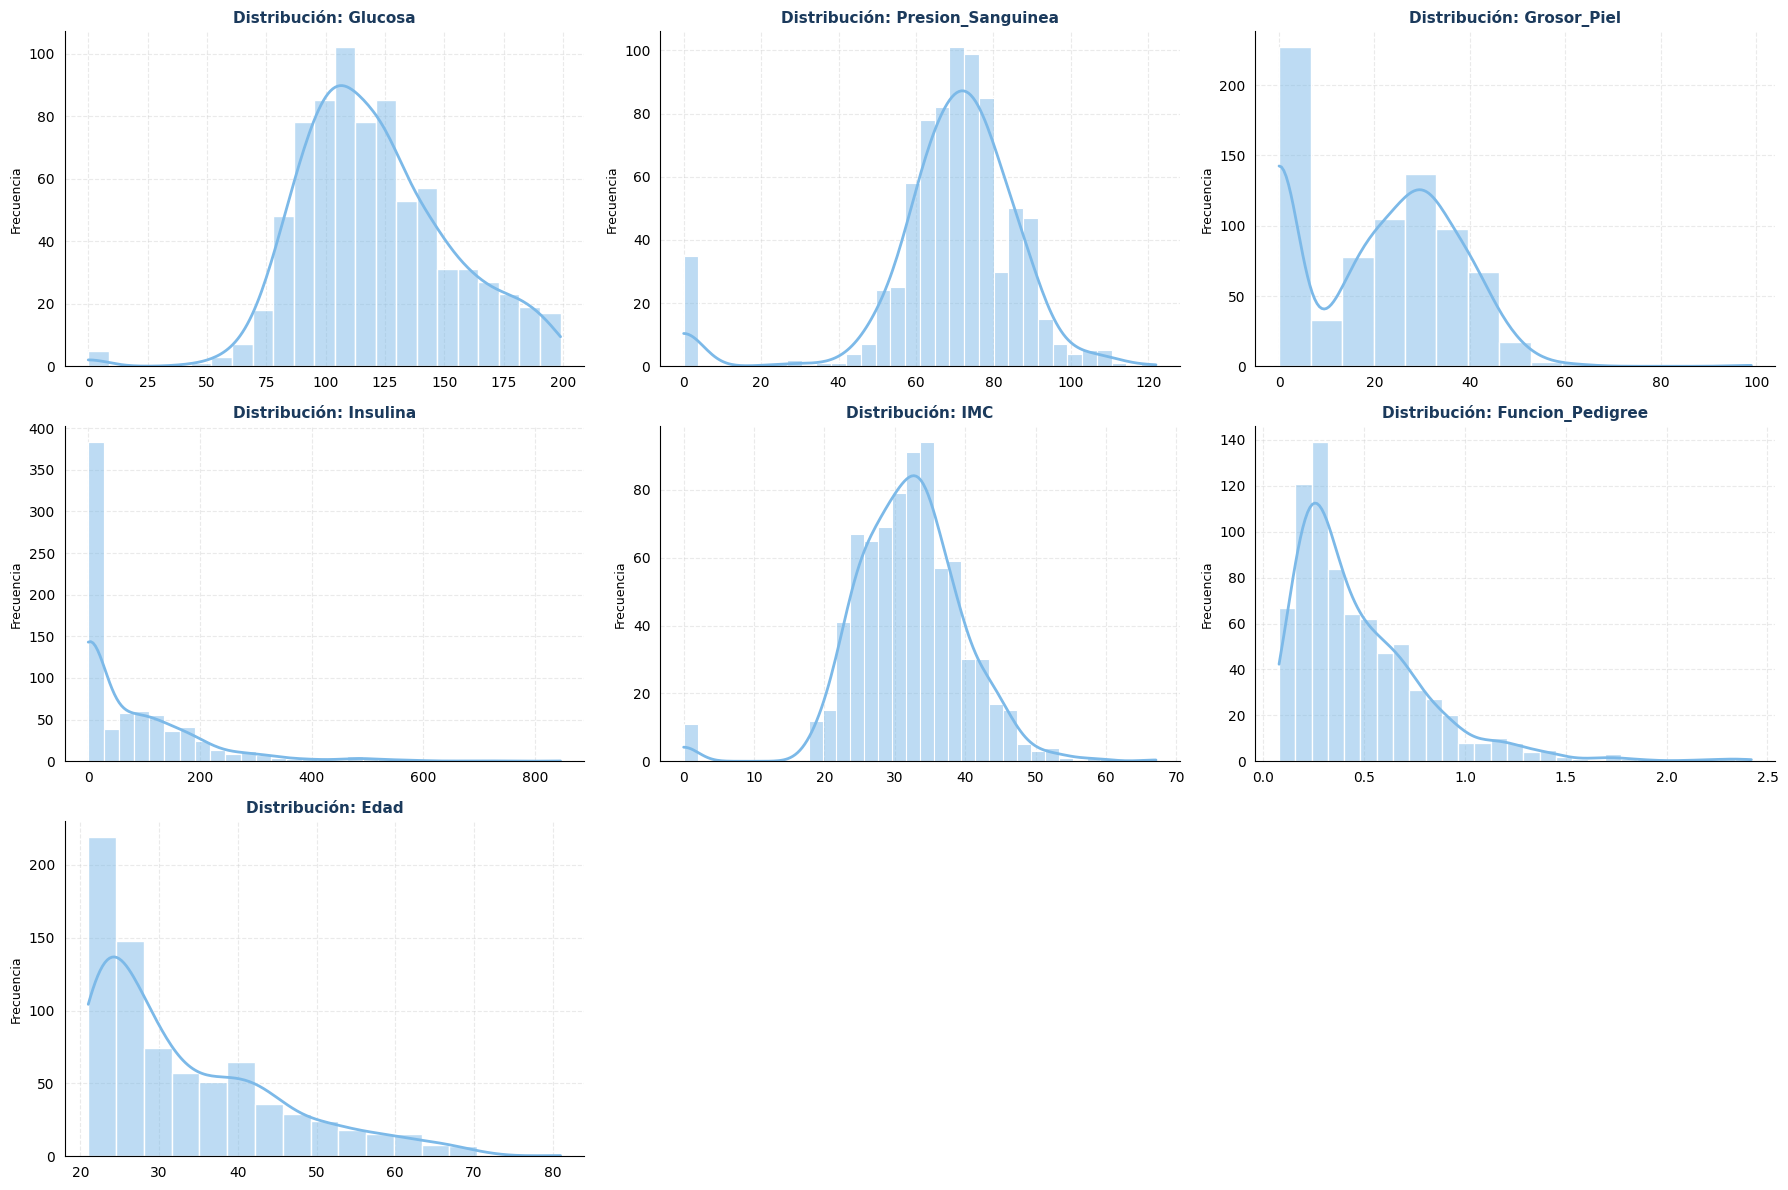

In [ ]:
# ==========================================
# 📊 BLOQUE 4A: HISTOGRAMAS NUMÉRICOS
# ==========================================

# Selección de variables numéricas continuas
numeric_cols = ['Glucosa', 'Presion_Sanguinea', 'Grosor_Piel',
                'Insulina', 'IMC', 'Funcion_Pedigree', 'Edad']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flat

for i, col in enumerate(numeric_cols):
    # Histograma con curva de densidad
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color=COLOR_2,
        line_kws={'color': COLOR_1, 'linewidth': 2},
        ax=axes[i]
    )

    # Estética de ejes
    axes[i].set_title(f'Distribución: {col}', fontsize=11, color=COLOR_1, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia', fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.4)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Eliminar ejes vacíos sobrantes si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

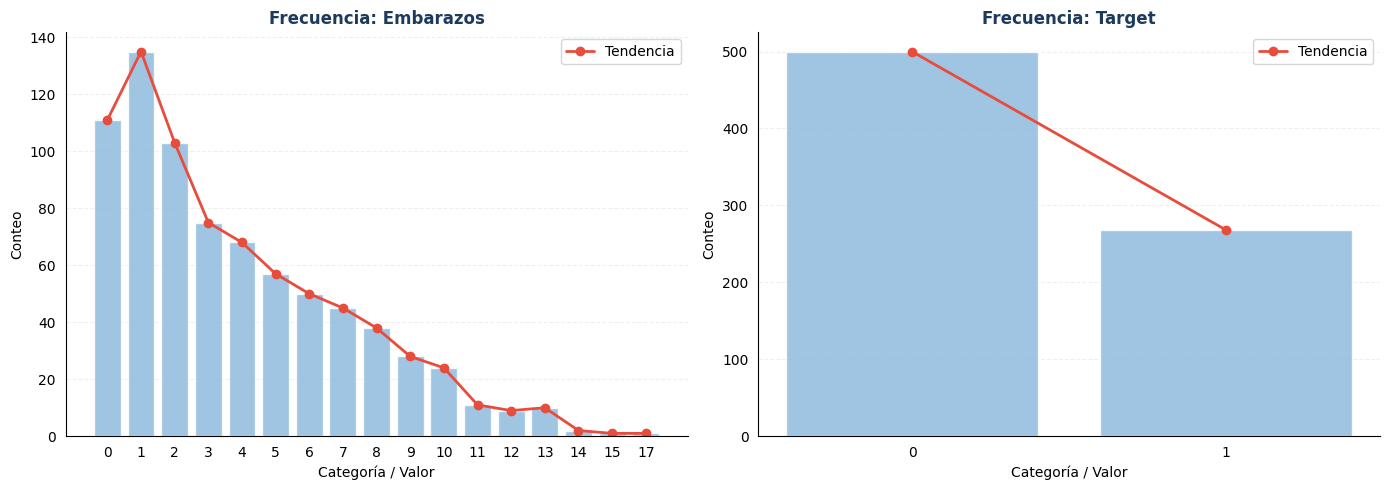

In [ ]:
# ==========================================
# 📊 BLOQUE 4B: DISTRIBUCIÓN VARIABLES DISCRETAS / CATEGÓRICAS
# ==========================================

# Variables discretas tratadas como categóricas para este análisis
categorical_cols = ['Embarazos', 'Target']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # 1. Gráfico de barras (Histograma categórico)
    sns.countplot(data=df, x=col, color=COLOR_2, ax=ax, alpha=0.8)

    # 2. Línea de Tendencia (Conectando los puntos superiores de las barras)
    counts = df[col].value_counts().sort_index()
    ax.plot(range(len(counts)), counts.values, color=COLOR_R,
            marker='o', linewidth=2, markersize=6, label='Tendencia')

    # Estética
    ax.set_title(f'Frecuencia: {col}', fontsize=12, color=COLOR_1, fontweight='bold')
    ax.set_xlabel('Categoría / Valor', fontsize=10)
    ax.set_ylabel('Conteo', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')
    ax.legend(loc='upper right')

    # Ocultar spines innecesarios
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

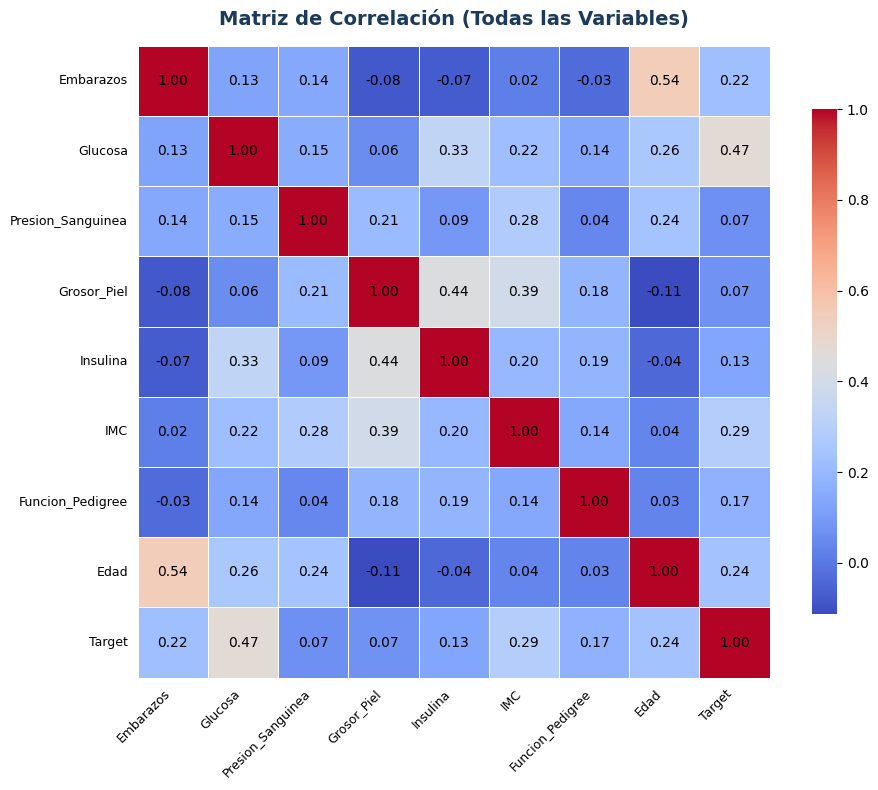

In [ ]:
# ==========================================
# 🔥 BLOQUE 5A: MATRIZ DE CORRELACIÓN GLOBAL
# ==========================================
plt.figure(figsize=(10, 8), facecolor='white')

# Cálculo de matriz
corr_matrix = df.corr()

# Mapa de calor estilizado
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10, "color": "black"}
)

plt.title('Matriz de Correlación (Todas las Variables)', fontsize=14, fontweight='bold', color=COLOR_1, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()



In [ ]:
# ==========================================
# 🔍 BLOQUE 5B: TOP 5 CORRELACIONES GENERALES (PARES)
# ==========================================

corr_unstacked = corr_matrix.unstack()

# Filtrar: Quitar correlaciones consigo mismo (1.0) y duplicados
mask = corr_unstacked.index.get_level_values(0) != corr_unstacked.index.get_level_values(1)
top_pairs = (corr_unstacked[mask]
             .drop_duplicates()
             .abs() # Nos interesa la fuerza (magnitud), ordenamos por valor absoluto
             .sort_values(ascending=False)
             .head(5)
             .reset_index())

# Renombrar para display
top_pairs.columns = ['Variable 1', 'Variable 2', 'Fuerza Correlación (Abs)']

# Visualización Tabular
print("📊 TOP 5 PARES DE VARIABLES CON MAYOR RELACIÓN:")
display(
    top_pairs.style
    .background_gradient(subset=['Fuerza Correlación (Abs)'], cmap='Reds')
    .format({"Fuerza Correlación (Abs)": "{:.3f}"})
    .set_properties(**{
        'background-color': '#f1f5f9',
        'color': 'black',
        'text-align': 'center'
    })
)

📊 TOP 5 PARES DE VARIABLES CON MAYOR RELACIÓN:


,Variable 1,Variable 2,Fuerza Correlación (Abs)
0,Embarazos,Edad,0.544
1,Glucosa,Target,0.467
2,Grosor_Piel,Insulina,0.437
3,Grosor_Piel,IMC,0.393
4,Glucosa,Insulina,0.331


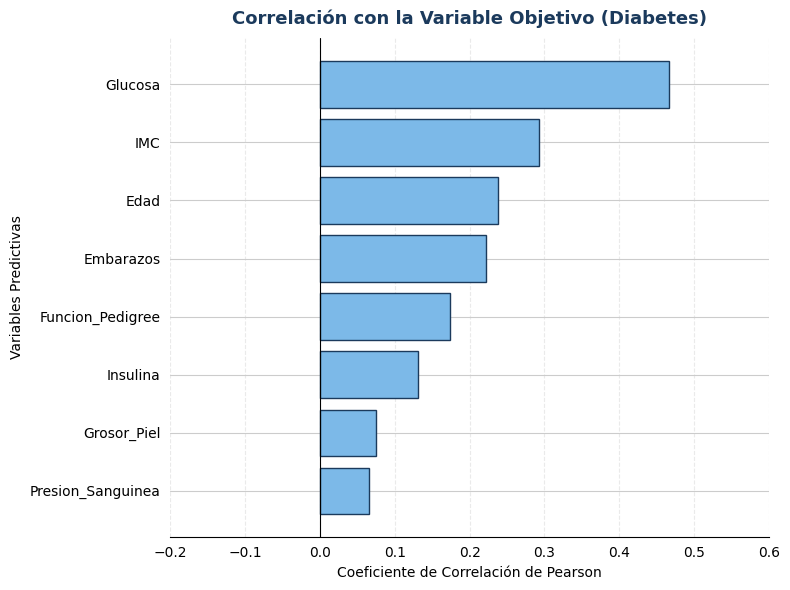

In [ ]:
# ==========================================
# 🎯 BLOQUE 5C: CORRELACIÓN CON VARIABLE OBJETIVO (TARGET)
# ==========================================

# Calcular correlación específica con el Target y ordenar
target_corr = df.corr()['Target'].drop('Target').sort_values(ascending=True)

# Gráfico de Barras Horizontal
plt.figure(figsize=(8, 6), facecolor='white')
bars = plt.barh(target_corr.index, target_corr.values, color=COLOR_2, edgecolor=COLOR_1)

plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.title('Correlación con la Variable Objetivo (Diabetes)', fontsize=13, fontweight='bold', color=COLOR_1, pad=10)
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=10)
plt.ylabel('Variables Predictivas', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.xlim(-0.2, 0.6) # Ajuste de escala para visualización

# Ocultar spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

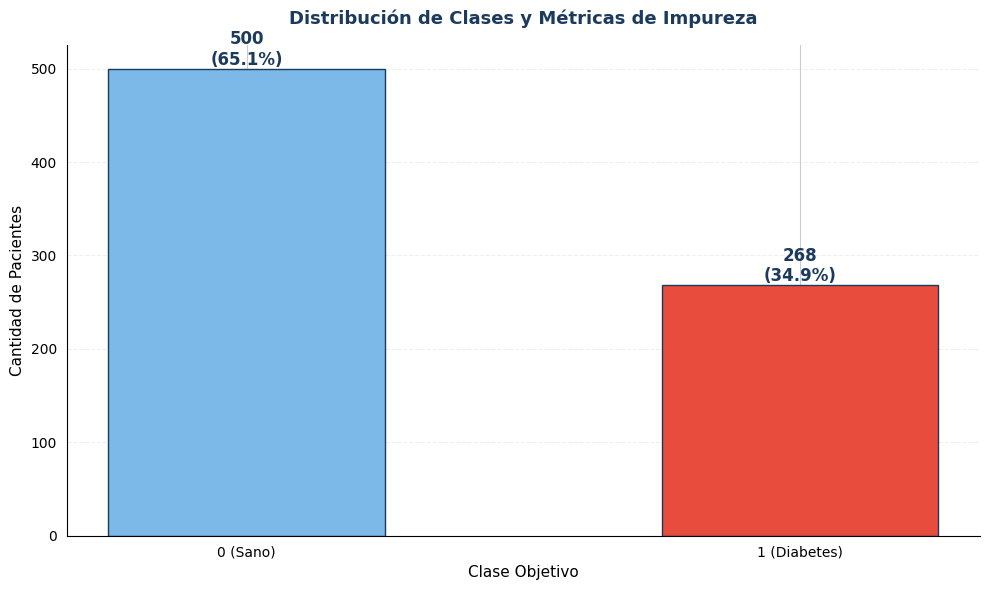

 RESUMEN NUMÉRICO:
Clase 0 (Sano): 500 instancias (65.10%)
Clase 1 (Diabetes): 268 instancias (34.90%)
------------------------------------------------
Ratio de Desbalance: 1.87 a favor de la Clase 0
Entropía de Shannon: 0.9331


In [ ]:
# ==========================================
# ⚖️ BLOQUE 6: ANÁLISIS DE DESEQUILIBRIO Y ENTROPÍA
# ==========================================

# 1. Cálculos de Métricas
target_counts = df['Target'].value_counts().sort_index()
n_0 = target_counts[0] # Clase 0 (Mayoría)
n_1 = target_counts[1] # Clase 1 (Minoría)
total = len(df)

# Probabilidades
p_0 = n_0 / total
p_1 = n_1 / total

# Ratio de Desbalance (Majority / Minority)
imbalance_ratio = n_0 / n_1

# Entropía de Shannon (Base 2)
entropy_val = - (p_0 * log2(p_0) + p_1 * log2(p_1))

# 2. Visualización Integrada
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Gráfico de Barras
bars = ax.bar(['0 (Sano)', '1 (Diabetes)'], [n_0, n_1],
               color=[COLOR_2, COLOR_R], edgecolor=COLOR_1, width=0.5)

# Anotaciones en las barras
for bar, count, pct in zip(bars, [n_0, n_1], [p_0, p_1]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({pct:.1%})',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color=COLOR_1)

# Estética final
ax.set_title('Distribución de Clases y Métricas de Impureza', fontsize=13, fontweight='bold', color=COLOR_1, pad=15)
ax.set_ylabel('Cantidad de Pacientes', fontsize=11)
ax.set_xlabel('Clase Objetivo', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Impresión en Consola
print(" RESUMEN NUMÉRICO:")
print(f"Clase 0 (Sano): {n_0} instancias ({p_0:.2%})")
print(f"Clase 1 (Diabetes): {n_1} instancias ({p_1:.2%})")
print(f"------------------------------------------------")
print(f"Ratio de Desbalance: {imbalance_ratio:.2f} a favor de la Clase 0")
print(f"Entropía de Shannon: {entropy_val:.4f}")

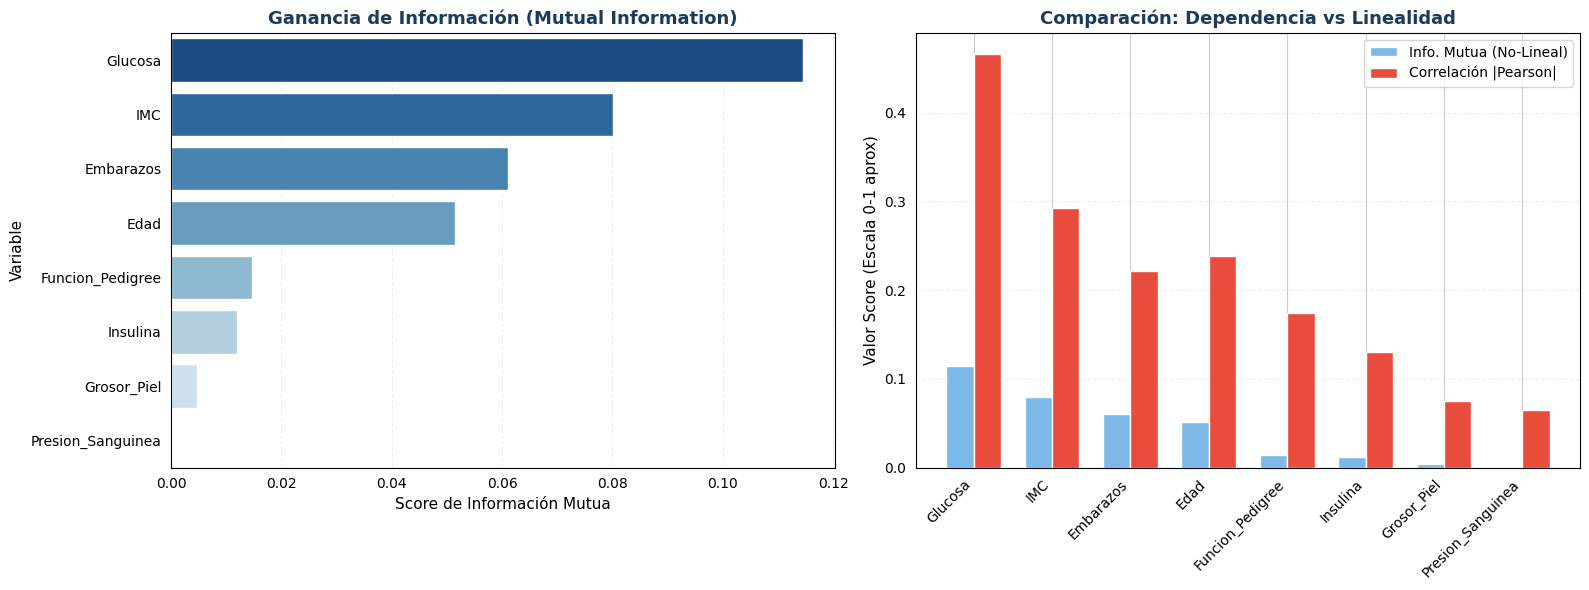

📊 RANKING DE IMPORTANCIA POR INFORMACIÓN MUTUA:


,Info_Mutua,Correlación_Pearson
Variable,,
Glucosa,0.115,0.467
IMC,0.080,0.293
Embarazos,0.061,0.222
Edad,0.051,0.238
Funcion_Pedigree,0.015,0.174
Insulina,0.012,0.131
Grosor_Piel,0.005,0.075
Presion_Sanguinea,0.000,0.065


In [ ]:
# ==========================================
# 🧠 BLOQUE 7: ANÁLISIS DE INFORMACIÓN MUTUA
# ==========================================

# 1. Preparación
X = df.drop(columns=['Target'])
y = df['Target']

# 2. Cálculo de Información Mutua (Discreta vs Continua)
mi_scores = mutual_info_classif(X, y, random_state=42, discrete_features=False)

# 3. Creación de DataFrame de Resultados
mi_df = pd.DataFrame({
    'Variable': X.columns,
    'Info_Mutua': mi_scores
}).sort_values(by='Info_Mutua', ascending=False).reset_index(drop=True)

# 4. Comparación con Correlación (Pearson) para detectar no-linearidad
correlation_vs_target = df.corr()['Target'].drop('Target')
comparison_df = mi_df.set_index('Variable').join(correlation_vs_target.rename('Correlación_Pearson'))
# Ordenar por Información Mutua
comparison_df = comparison_df.sort_values('Info_Mutua', ascending=False)

# 5. Visualización Dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Ranking de Información Mutua ---
sns.barplot(x='Info_Mutua', y='Variable', data=mi_df, palette='Blues_r', ax=ax1)
ax1.set_title('Ganancia de Información (Mutual Information)', fontsize=13, fontweight='bold', color=COLOR_1)
ax1.set_xlabel('Score de Información Mutua', fontsize=11)
ax1.set_ylabel('Variable', fontsize=11)
ax1.grid(axis='x', linestyle='--', alpha=0.3)

# --- Gráfico 2: Comparación (MI vs Correlación) ---
x_pos = np.arange(len(comparison_df))
width = 0.35

bars_mi = ax2.bar(x_pos - width/2, comparison_df['Info_Mutua'], width, label='Info. Mutua (No-Lineal)', color=COLOR_2)
bars_corr = ax2.bar(x_pos + width/2, comparison_df['Correlación_Pearson'].abs(), width, label='Correlación |Pearson|', color=COLOR_R)

ax2.set_title('Comparación: Dependencia vs Linealidad', fontsize=13, fontweight='bold', color=COLOR_1)
ax2.set_ylabel('Valor Score (Escala 0-1 aprox)', fontsize=11)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Tabla Resumen
print("📊 RANKING DE IMPORTANCIA POR INFORMACIÓN MUTUA:")
display(comparison_df.style.background_gradient(subset=['Info_Mutua'], cmap='Blues').format("{:.3f}"))

In [ ]:
# ==========================================
# ✂️ BLOQUE 8: SEGMENTACIÓN Y PREPARACIÓN FE
# ==========================================

# 1. Definición de Matrices
X = df.drop(columns=['Target'])
y = df['Target']

# 2. Segmentación 80/20 (Estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Copia para Feature Engineering (Solo Train)
# Creamos esta copia para experimentar con nuevas variables sin romper el original
df_fe = X_train.copy()
df_fe['Target'] = y_train # Agregamos el target temporalmente si necesitamos cálculos condicionales

# 4. Validación de Dimensiones
print("📊 DIMENSIONES DE LOS SUBCONJUNTOS:")
print(f"Dataset Original: {df.shape[0]} filas")
print(f"Train Set (80%): {X_train.shape[0]} filas ({len(X_train)/len(df):.1%})")
print(f"Test Set  (20%): {X_test.shape[0]} filas ({len(X_test)/len(df):.1%})")

print("\n🧬 Distribución del Target en Train vs Test (Verificación Estratificación):")
print(f"Train - Clase 0: {sum(y_train==0)} | Clase 1: {sum(y_train==1)}")
print(f"Test  - Clase 0: {sum(y_test==0)} | Clase 1: {sum(y_test==1)}")

📊 DIMENSIONES DE LOS SUBCONJUNTOS:
Dataset Original: 768 filas
Train Set (80%): 614 filas (79.9%)
Test Set  (20%): 154 filas (20.1%)

🧬 Distribución del Target en Train vs Test (Verificación Estratificación):
Train - Clase 0: 400 | Clase 1: 214
Test  - Clase 0: 100 | Clase 1: 54


In [ ]:
# ==========================================
# 🧬 BLOQUE 9 FEATURE ENGINEERING
# ==========================================

# 1. Creación de Ratios Específicos
rf = RelativeFeatures(
    variables=['Insulina', 'Presion_Sanguinea', 'IMC'],
    reference=['Glucosa', 'IMC', 'Edad'],
    func=['div'],
    fill_value=1 # Si Glucosa es 0, usamos 1 como divisor para evitar el error
)

df_fe = rf.fit_transform(df_fe)

# Renombramos a tu gusto
rename_map = {
    'Insulina_div_Glucosa': 'Ratio_Insulina_Glucosa',
    'Presion_Sanguinea_div_IMC': 'Ratio_Presion_IMC',
    'IMC_div_Edad': 'Ratio_IMC_Edad'
}
df_fe.rename(columns=rename_map, inplace=True)

# 2. Creación de Variables Categóricas (Binning)
discretiser = ArbitraryDiscretiser(
    binning_dict={
        'IMC': [0, 25, 30, 100],
        'Edad': [0, 30, 50, 100]
    },
    return_object=True,
    return_boundaries=False
)

df_fe = discretiser.fit_transform(df_fe)

# Mapeo manual
bmi_map = {0: 'Normal', 1: 'Sobrepeso', 2: 'Obesidad'}
edad_map = {0: 'Joven', 1: 'Adulto', 2: 'Adulto_Mayor'}

df_fe['IMC_Categoria'] = df_fe['IMC'].map(bmi_map)
df_fe['Edad_Categoria'] = df_fe['Edad'].map(edad_map)

print("✅ Variables Creadas (Manejando Ceros en Divisor):")
display(df_fe[['Ratio_Insulina_Glucosa', 'Ratio_Presion_IMC', 'Ratio_IMC_Edad', 'IMC_Categoria', 'Edad_Categoria']].head(3))

✅ Variables Creadas (Manejando Ceros en Divisor):


,Ratio_Insulina_Glucosa,Ratio_Presion_IMC,Ratio_IMC_Edad,IMC_Categoria,Edad_Categoria
353,0.477778,2.279412,1.133333,Sobrepeso,Joven
711,0.174603,2.635135,0.740000,Sobrepeso,Adulto
373,0.895238,1.661891,1.396000,Obesidad,Joven


In [ ]:
# ==========================================
# 🔄 BLOQUE 10: ONE HOT ENCODING (OHE)
# ==========================================

# 1. Configuración
target_vars = ['IMC_Categoria', 'Edad_Categoria']

# 2. Instanciación y Transformación
encoder = OneHotEncoder(variables=target_vars, drop_last=True)
df_fe = encoder.fit_transform(df_fe)

# 3. Validación Estructural
dummies_creadas = [c for c in df_fe.columns if 'Categoria' in c]

print(f"✅ Encoding completado.")
print(f"   Shape Final: {df_fe.shape[0]} filas | {df_fe.shape[1]} columnas")
print(f"   Nuevas Dummies ({len(dummies_creadas)}):")
print(f"   {dummies_creadas}")

✅ Encoding completado.
   Shape Final: 614 filas | 22 columnas
   Nuevas Dummies (4):
   ['IMC_Categoria_Sobrepeso', 'IMC_Categoria_Obesidad', 'Edad_Categoria_Joven', 'Edad_Categoria_Adulto']


In [ ]:
# ==========================================
# 🎯 BLOQUE 11 DEFINITIVO: STACK DE SELECCIÓN
# ==========================================

# 0. PREPARACIÓN DE DATOS
X_sel = df_fe.drop(columns=['Target'])
y_sel = df_fe['Target']
features_names = X_sel.columns

# 1. FILTER (ANOVA)
anova = SelectKBest(score_func=f_classif, k='all')
anova.fit(X_sel, y_sel)
mask_anova = anova.pvalues_ < 0.05

# 2. EMBEDDED (Lasso L1)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=1000)
lasso_selector = SelectFromModel(lasso, prefit=False, threshold='mean')
lasso_selector.fit(X_sel, y_sel)
mask_lasso = lasso_selector.get_support()

# 3. BASELINE
mask_baseline = pd.Series([True] * len(features_names), index=features_names)

# 4. BONA (BORUTA)
# Definimos 'rf' explícitamente aquí
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(rf, n_estimators='auto', max_iter=50, random_state=42, verbose=0)
boruta.fit(X_sel.values, y_sel.values)
mask_bona = boruta.support_

# 5. VOTACIÓN Y MATRIZ
voting_table = pd.DataFrame({
    'Variable': features_names,
    'ANOVA': mask_anova.astype(int),
    'Lasso': mask_lasso.astype(int),
    'Baseline': mask_baseline.astype(int),
    'Boruta': mask_bona.astype(int)
})

# Votos confirmatorios (sin contar baseline)
voting_table['Votos'] = voting_table[['ANOVA', 'Lasso', 'Boruta']].sum(axis=1)

# Criterio: Aprobada por al menos 2 métodos
final_features = voting_table[(voting_table['Votos'] >= 2)].sort_values('Votos', ascending=False)

print("✅ Selección finalizada.")
print(f"   Variables elegidas: {len(final_features)}")
display(final_features)

# Dataset final listo para escalar
X_train_selected = X_sel[final_features['Variable'].tolist()]

✅ Selección finalizada.
   Variables elegidas: 13


,Variable,ANOVA,Lasso,Baseline,Boruta,Votos
Edad_Categoria_Joven,Edad_Categoria_Joven,1,1,1,1,3
Ratio_Presion_IMC,Ratio_Presion_IMC,1,1,1,1,3
Presion_Sanguinea,Presion_Sanguinea,1,0,1,1,2
Glucosa,Glucosa,1,0,1,1,2
Embarazos,Embarazos,1,0,1,1,2
IMC,IMC,1,0,1,1,2
Insulina,Insulina,1,0,1,1,2
Funcion_Pedigree,Funcion_Pedigree,1,0,1,1,2
Edad,Edad,1,0,1,1,2
IMC_div_Glucosa,IMC_div_Glucosa,1,0,1,1,2


In [ ]:
# ==========================================
# 📏 BLOQUE 12: ESCALADO (CON PASO DE MAPEO MANUAL)
# ==========================================
from sklearn.preprocessing import StandardScaler
from feature_engine.creation import RelativeFeatures
from feature_engine.discretisation import ArbitraryDiscretiser

# 1. TRANSFORMADOR DE RATIOS
rf_transformer = RelativeFeatures(
    variables=['Insulina', 'Presion_Sanguinea', 'IMC'],
    reference=['Glucosa', 'IMC', 'Edad'],
    func=['div'],
    fill_value=1
)

# 2. RE-CREACIÓN DE DISCRETISER (Para asegurar control absoluto)
# Forzamos return_object=False para que devuelva 0, 1, 2 y podamos mapear manualmente
discretiser = ArbitraryDiscretiser(
    binning_dict={
        'IMC': [0, 25, 30, 100],
        'Edad': [0, 30, 50, 100]
    },
    return_object=False,
    return_boundaries=False
)

# 3. PIPELINE DE ENTRENAMIENTO (FIT EN TRAIN)
# A. Ratios
rf_transformer.fit(X_train)
X_train_temp = rf_transformer.transform(X_train)
X_train_temp = X_train_temp.rename(columns=rename_map)

# B. Binning (Devuelve 0, 1, 2)
discretiser.fit(X_train_temp)
X_train_temp = discretiser.transform(X_train_temp)

# C. MAPEO MANUAL (El paso faltante que causa el KeyError)
# Transformamos los números en las etiquetas de texto que espera el Encoder
bmi_map = {0: 'Normal', 1: 'Sobrepeso', 2: 'Obesidad'}
edad_map = {0: 'Joven', 1: 'Adulto', 2: 'Adulto_Mayor'}

X_train_temp['IMC_Categoria'] = X_train_temp['IMC'].map(bmi_map)
X_train_temp['Edad_Categoria'] = X_train_temp['Edad'].map(edad_map)

# D. One Hot Encoding (Ahora encuentra las columnas textuales)
encoder.fit(X_train_temp)

# 4. PIPELINE DE TEST
# A. Ratios
X_test_fe = rf_transformer.transform(X_test)
X_test_fe = X_test_fe.rename(columns=rename_map)

# B. Binning
X_test_fe = discretiser.transform(X_test_fe)

# C. Mapeo Manual (Mismo mapeo para el test)
X_test_fe['IMC_Categoria'] = X_test_fe['IMC'].map(bmi_map)
X_test_fe['Edad_Categoria'] = X_test_fe['Edad'].map(edad_map)

# D. Encoding
X_test_fe = encoder.transform(X_test_fe)

# 5. FILTRADO Y ESCALADO FINAL
selected_cols = final_features['Variable'].tolist()
X_test_selected = X_test_fe[selected_cols]

scaler = StandardScaler()
scaler.fit(X_train_selected)

X_train_scaled = scaler.transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# 6. DATAFRAME FINAL
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_cols)

print("✅ Pipeline sincronizado (con mapeo manual incluido).")
print(f"   Train: {X_train_scaled.shape}")
print(f"   Test:  {X_test_scaled.shape}")

✅ Pipeline sincronizado (con mapeo manual incluido).
   Train: (614, 13)
   Test:  (154, 13)


In [ ]:
# ==========================================
# ⚙️ BLOQUE 13.1: GRIDSEARCH (FASE DE BÚSQUEDA)
# ==========================================
from sklearn.model_selection import GridSearchCV

# Configuración de Modelos y Grillas (Mismas que antes)
modelos_y_params = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7], 'min_samples_split': [2, 5]}
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'params': {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
    },
    'SVM (RBF)': {
        'model': SVC(probability=True, random_state=42),
        'params': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
    }
}

# Contenedor central para los mejores modelos entrenados
tuned_models = {}

print("⚙️ Ejecutando GridSearch para encontrar el mejor modelo de cada tipo...")

for nombre, config in modelos_y_params.items():
    print(f"   🔄 Buscando mejores parámetros para: {nombre}...")

    gs = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    # Entrenamos y encontramos el mejor
    gs.fit(X_train_scaled, y_train)

    # Guardamos el mejor estimador YA ENTRENADO
    tuned_models[nombre] = gs.best_estimator_

    print(f"   ✅ {nombre} optimizado. Mejor AUC: {gs.best_score_:.4f}")

print("\n✅ BLOQUE 13.1 FINALIZADO. Modelos guardados en 'tuned_models'.")

⚙️ Ejecutando GridSearch para encontrar el mejor modelo de cada tipo...
   🔄 Buscando mejores parámetros para: Logistic Regression...
   ✅ Logistic Regression optimizado. Mejor AUC: 0.8415
   🔄 Buscando mejores parámetros para: Random Forest...
   ✅ Random Forest optimizado. Mejor AUC: 0.8357
   🔄 Buscando mejores parámetros para: XGBoost...
   ✅ XGBoost optimizado. Mejor AUC: 0.8158
   🔄 Buscando mejores parámetros para: SVM (RBF)...
   ✅ SVM (RBF) optimizado. Mejor AUC: 0.8356
   🔄 Buscando mejores parámetros para: KNN...
   ✅ KNN optimizado. Mejor AUC: 0.8249
   🔄 Buscando mejores parámetros para: Gradient Boosting...
   ✅ Gradient Boosting optimizado. Mejor AUC: 0.8221

✅ BLOQUE 13.1 FINALIZADO. Modelos guardados en 'tuned_models'.


In [ ]:
# ==========================================
# 📊 BLOQUE 13.2: EVALUACIÓN Y PIPELINE DE RESULTADOS
# ==========================================

model_preds = {}
model_probas = {} # Guardaremos probabilidades para la Curva ROC

results_list = []

print("📊 Evaluando modelos tuneados en Test Set...")

for nombre, modelo in tuned_models.items():
    # 1. Predicciones
    y_pred = modelo.predict(X_test_scaled)

    # 2. Probabilidades (Para AUC y Curva ROC)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

    # 3. Cálculo de Métricas
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # 4. Almacenamiento en el Pipeline de Datos
    results_list.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

    # Guardamos predicciones para los gráficos (Matriz de Confusión, etc.)
    model_preds[nombre] = y_pred
    model_probas[nombre] = y_proba

# 5. Creación del Ranking Final
df_ranking = pd.DataFrame(results_list).sort_values(by='ROC-AUC', ascending=False)

print("✅ BLOQUE 13.2 FINALIZADO. Datos guardados en 'model_preds' y 'model_probas'.")

display(
    df_ranking.style
    .background_gradient(subset=['Accuracy', 'Recall', 'F1-Score', 'ROC-AUC'], cmap='Blues')
    .format("{:.3f}", subset=['Accuracy', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_properties(**{
        'background-color': '#1B3A5C',
        'color': '#7CB9E8',
        'font-weight': 'bold'
    }, subset=['Modelo'])
)

📊 Evaluando modelos tuneados en Test Set...
✅ BLOQUE 13.2 FINALIZADO. Datos guardados en 'model_preds' y 'model_probas'.


,Modelo,Accuracy,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.734,0.556,0.594,0.840
4,KNN,0.779,0.593,0.653,0.830
1,Random Forest,0.747,0.556,0.606,0.823
3,SVM (RBF),0.753,0.389,0.525,0.815
2,XGBoost,0.727,0.463,0.543,0.807
5,Gradient Boosting,0.747,0.537,0.598,0.799


In [ ]:
# ==========================================
# 🏗️ CLASE ARENA MODELOS
# ==========================================
# --- CLASES AUXILIARES ---

class NoSelector(BaseEstimator, TransformerMixin):
    """No hace nada, pasa los datos tal cual."""
    def fit(self, X, y=None): return self
    def transform(self, X): return X

class BorutaSelector(BaseEstimator, TransformerMixin):
    """Wrapper para usar Boruta dentro de un Pipeline de Sklearn."""
    def __init__(self, max_iter=25, random_state=42):
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        # Boruta requiere numpy arrays
        X_arr = X.values if isinstance(X, pd.DataFrame) else X

        # Usamos RF ligero interno para Boruta
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

        self.boruta = BorutaPy(
            rf,
            n_estimators='auto',
            max_iter=self.max_iter,
            random_state=self.random_state,
            verbose=0
        )
        self.boruta.fit(X_arr, y)
        return self

    def transform(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return X_arr[:, self.boruta.support_]

# --- CLASE PRINCIPAL ---

class ArenaModelos:
    def __init__(self, X_train, y_train, scoring='recall'):
        self.X_train = X_train
        self.y_train = y_train
        self.scoring = scoring
        self.colores = {'train': '#E74C3C', 'test': '#1B3A5C'}

    def _get_estrategias(self):
        """Diccionario de métodos de selección a probar."""
        return {
            '1. Baseline': NoSelector(),
            '2. ANOVA (Filter)': SelectKBest(score_func=f_classif, k=10),
            '3. Lasso (Embedded)': SelectFromModel(
                LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=500, random_state=42)
            ),
            '4. RF Import. (Embedded)': SelectFromModel(
                RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1), threshold='median'
            ),
            '5. Boruta (Ensemble)': BorutaSelector(max_iter=25),
        }

    def evaluar_modelo_completo(self, nombre, estimator, param_grid):
        """Ejecuta GridSearch, devuelve el ganador Y EL HISTORIAL COMPLETO."""
        print(f"\n{'='*70}")
        print(f"🔍 ANALIZANDO MODELO: {nombre}")
        print(f"{'='*70}")

        estrategias = self._get_estrategias()
        resultados_detalle = {}
        mejor_score = -1
        mejor_pipe = None
        mejor_nombre = ""

        historial_pipelines = {}

        for nombre_sel, selector in estrategias.items():
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('selector', selector),
                ('clf', estimator)
            ])

            params = {f'clf__{k}': v for k, v in param_grid.items()}
            if isinstance(selector, SelectKBest):
                params['selector__k'] = [5, 10, 13]

            grid = GridSearchCV(pipe, params, cv=3, scoring=self.scoring, n_jobs=-1, verbose=0)
            grid.fit(self.X_train, self.y_train)

            score = grid.best_score_
            resultados_detalle[nombre_sel] = score

            historial_pipelines[nombre_sel] = grid.best_estimator_

            if score > mejor_score:
                mejor_score = score
                mejor_pipe = grid.best_estimator_
                mejor_nombre = nombre_sel

        # Mostrar Tabla Comparativa
        df_comp = pd.DataFrame.from_dict(resultados_detalle, orient='index', columns=[f'{self.scoring.capitalize()} Score'])
        df_comp = df_comp.sort_values(by=f'{self.scoring.capitalize()} Score', ascending=False)
        print(df_comp.to_string())
        print(f"\n🏆 GANADOR ABSOLUTO: {mejor_nombre} (Score: {mejor_score:.4f})")

        # Graficar
        self._graficar_curva(mejor_pipe, nombre)

        # <--- IMPORTANTE: Retornamos 3 cosas: Ganador, Score, Historial Completo
        return mejor_pipe, mejor_score, historial_pipelines

    def _graficar_curva(self, pipe, nombre):
        train_sizes, train_scores, test_scores = learning_curve(
            pipe, self.X_train, self.y_train, cv=3, scoring=self.scoring,
            train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1, shuffle=True
        )

        plt.figure(figsize=(8, 4), facecolor='white')
        plt.plot(train_sizes, np.mean(train_scores, 1), 'o-', color=self.colores['train'], label='Train')
        plt.plot(train_sizes, np.mean(test_scores, 1), 'o-', color=self.colores['test'], label='Validation')
        plt.title(f'Learning Curve: {nombre}', fontweight='bold', color='#1B3A5C')
        plt.xlabel('Samples'); plt.ylabel(self.scoring.capitalize()); plt.legend()
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
# ==========================================
# 🗂️ INICIALIZACIÓN DE HISTORIAL GLOBAL
# ==========================================
global_history = []

print("✅ Contenedor global iniciado. Ahora puedes ejecutar las celdas de modelos.")

✅ Contenedor global iniciado. Ahora puedes ejecutar las celdas de modelos.



🔍 ANALIZANDO MODELO: Logistic Regression
                          Recall Score
2. ANOVA (Filter)             0.593897
1. Baseline                   0.579682
4. RF Import. (Embedded)      0.570423
5. Boruta (Ensemble)          0.565923
3. Lasso (Embedded)           0.565662

🏆 GANADOR ABSOLUTO: 2. ANOVA (Filter) (Score: 0.5939)


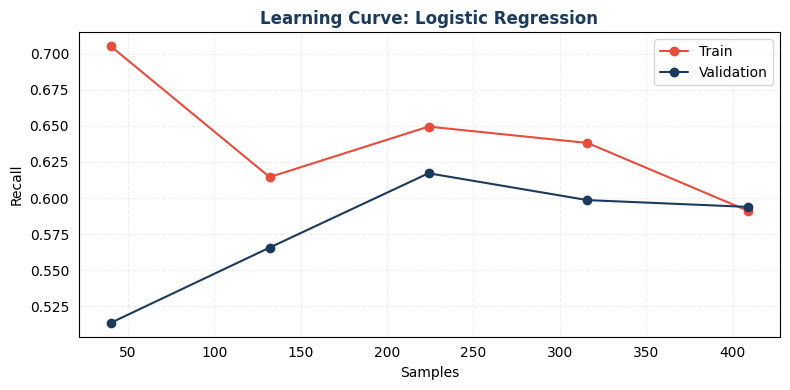

In [ ]:
# ==========================================
# 📉 MODELO 1: REGRESIÓN LOGÍSTICA
# ==========================================
ganador_log, score_log, hist_log = arena.evaluar_modelo_completo(
    nombre='Logistic Regression',
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}
)
# Guardamos el historial
global_history.append(('Logistic Regression', hist_log))


🔍 ANALIZANDO MODELO: Random Forest
                          Recall Score
2. ANOVA (Filter)             0.589332
1. Baseline                   0.547340
3. Lasso (Embedded)           0.547209
5. Boruta (Ensemble)          0.505086
4. RF Import. (Embedded)      0.500391

🏆 GANADOR ABSOLUTO: 2. ANOVA (Filter) (Score: 0.5893)


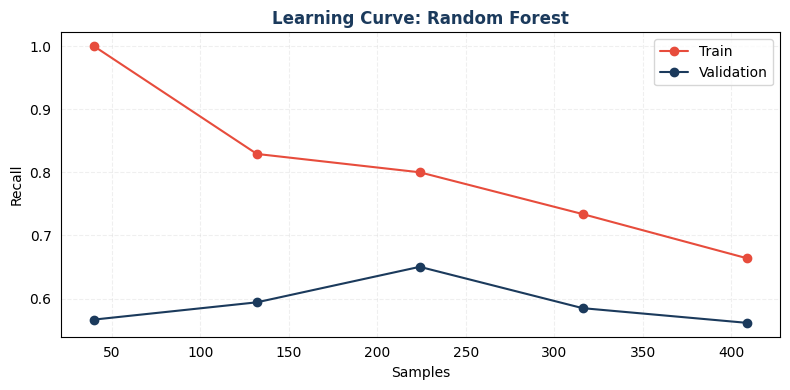

In [ ]:
# ==========================================
# 🌲 MODELO 2: RANDOM FOREST
# ==========================================
ganador_rf, score_rf, hist_rf = arena.evaluar_modelo_completo(
    nombre='Random Forest',
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={'n_estimators': [50, 100], 'max_depth': [3, 5], 'min_samples_split': [2, 5]}
)
global_history.append(('Random Forest', hist_rf))


🔍 ANALIZANDO MODELO: XGBoost
                          Recall Score
2. ANOVA (Filter)             0.598657
1. Baseline                   0.584181
3. Lasso (Embedded)           0.570423
5. Boruta (Ensemble)          0.570292
4. RF Import. (Embedded)      0.561163

🏆 GANADOR ABSOLUTO: 2. ANOVA (Filter) (Score: 0.5987)


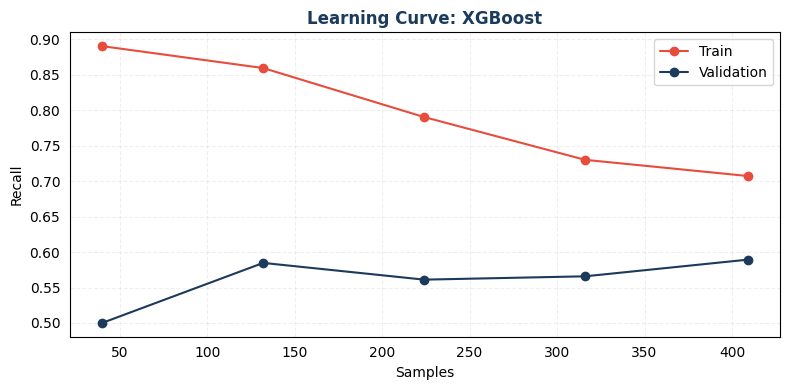

In [ ]:
# ==========================================
# 🚀 MODELO 3: XGBOOST
# ==========================================
ganador_xgb, score_xgb, hist_xgb = arena.evaluar_modelo_completo(
    nombre='XGBoost',
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid={'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
)
global_history.append(('XGBoost', hist_xgb))


🔍 ANALIZANDO MODELO: SVM (RBF)
                          Recall Score
1. Baseline                   0.607786
2. ANOVA (Filter)             0.607786
3. Lasso (Embedded)           0.589006
4. RF Import. (Embedded)      0.556599
5. Boruta (Ensemble)          0.537624

🏆 GANADOR ABSOLUTO: 1. Baseline (Score: 0.6078)


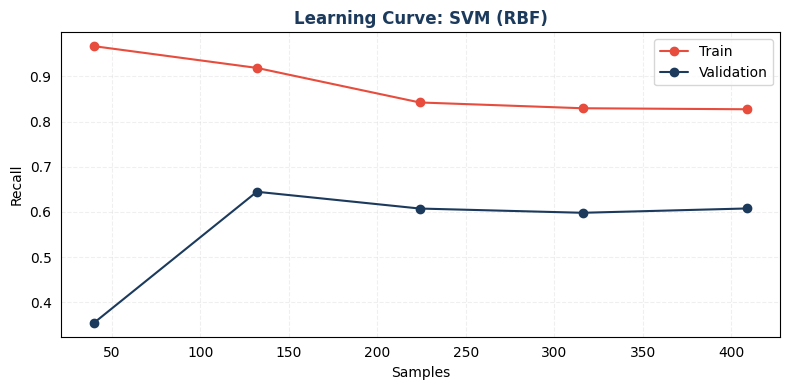

In [ ]:
# ==========================================
# ⭕ MODELO 4: SVM (RBF)
# ==========================================
ganador_svm, score_svm, hist_svm = arena.evaluar_modelo_completo(
    nombre='SVM (RBF)',
    estimator=SVC(probability=True, random_state=42),
    param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
)
global_history.append(('SVM (RBF)', hist_svm))


🔍 ANALIZANDO MODELO: KNN
                          Recall Score
2. ANOVA (Filter)             0.598461
1. Baseline                   0.575248
3. Lasso (Embedded)           0.561424
5. Boruta (Ensemble)          0.561163
4. RF Import. (Embedded)      0.542514

🏆 GANADOR ABSOLUTO: 2. ANOVA (Filter) (Score: 0.5985)


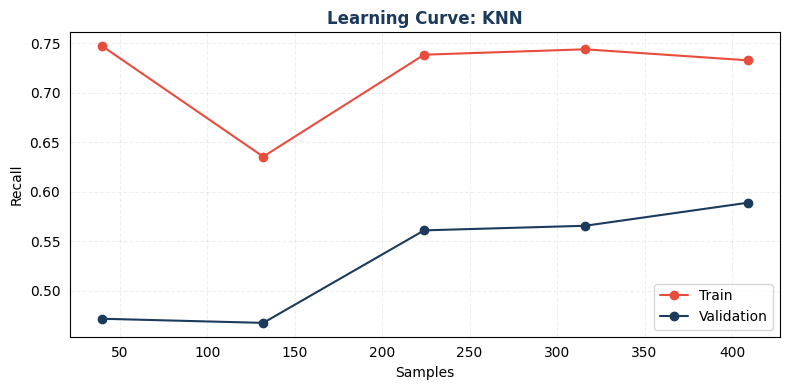

In [218]:
# ==========================================
# 📍 MODELO 5: KNN
# ==========================================
ganador_knn, score_knn, hist_knn = arena.evaluar_modelo_completo(
    nombre='KNN',
    estimator=KNeighborsClassifier(),
    param_grid={'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
)
global_history.append(('KNN', hist_knn))


🔍 ANALIZANDO MODELO: Gradient Boosting
                          Recall Score
2. ANOVA (Filter)             0.589267
4. RF Import. (Embedded)      0.560902
1. Baseline                   0.551643
3. Lasso (Embedded)           0.547209
5. Boruta (Ensemble)          0.542384

🏆 GANADOR ABSOLUTO: 2. ANOVA (Filter) (Score: 0.5893)


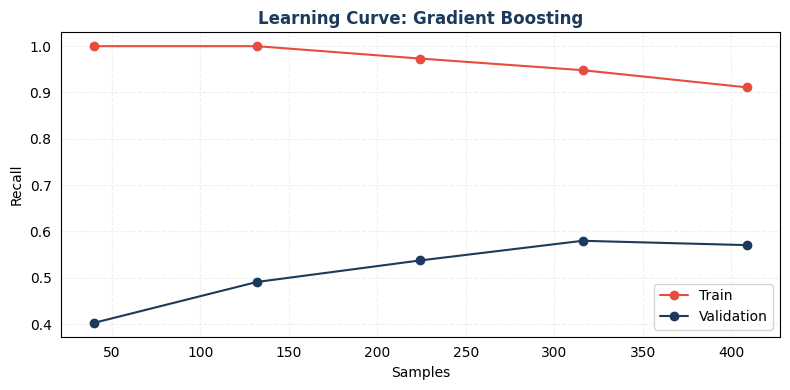

In [ ]:
# ==========================================
# 🌿 MODELO 6: GRADIENT BOOSTING
# ==========================================
ganador_gbc, score_gbc, hist_gbc = arena.evaluar_modelo_completo(
    nombre='Gradient Boosting',
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid={'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
)
global_history.append(('Gradient Boosting', hist_gbc))


🔍 ANALIZANDO MODELO: AdaBoost
                          Recall Score
2. ANOVA (Filter)             0.570683
1. Baseline                   0.561228
3. Lasso (Embedded)           0.561163
5. Boruta (Ensemble)          0.556338
4. RF Import. (Embedded)      0.546948

🏆 GANADOR ABSOLUTO: 2. ANOVA (Filter) (Score: 0.5707)


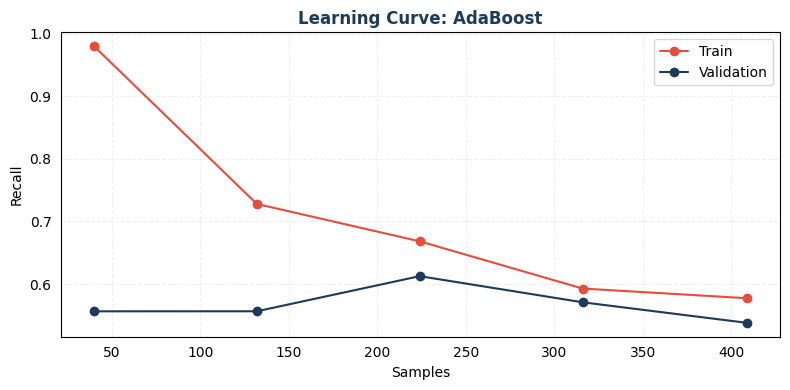

In [219]:
# ==========================================
# ⚡ MODELO 7: ADA BOOST
# ==========================================
ganador_ada, score_ada, hist_ada = arena.evaluar_modelo_completo(
    nombre='AdaBoost',
    estimator=AdaBoostClassifier(random_state=42),
    param_grid={'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]}
)
global_history.append(('AdaBoost', hist_ada))

📊 Generando Matrices de Confusión detalladas...


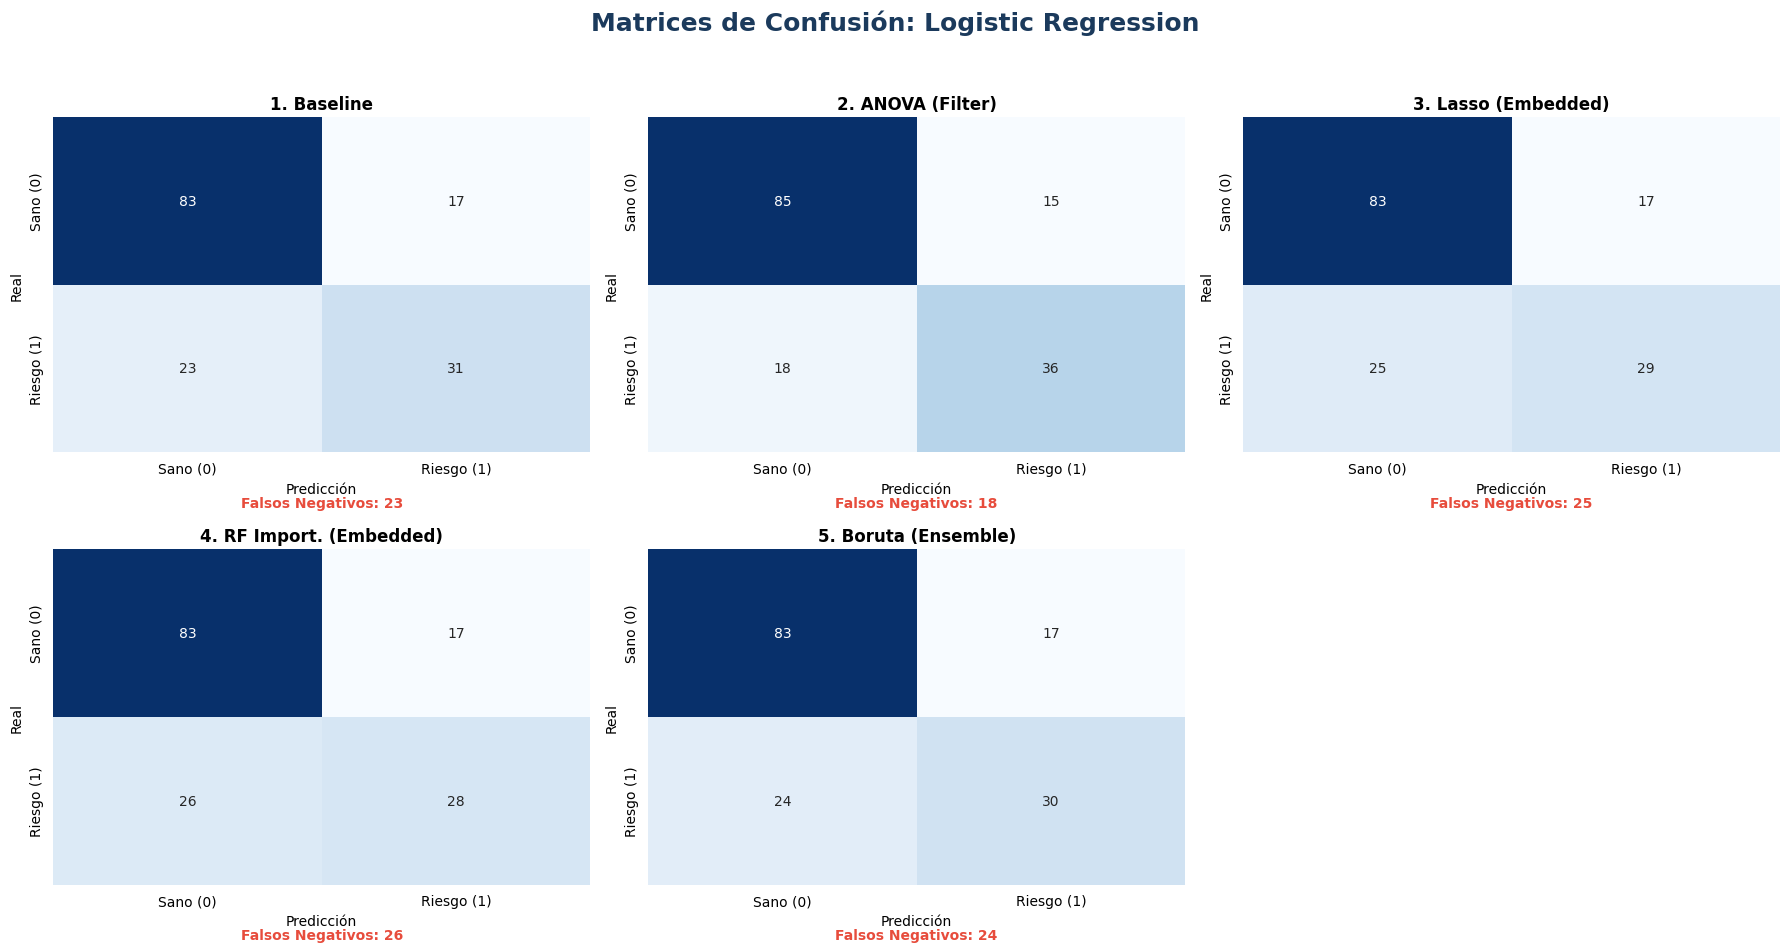

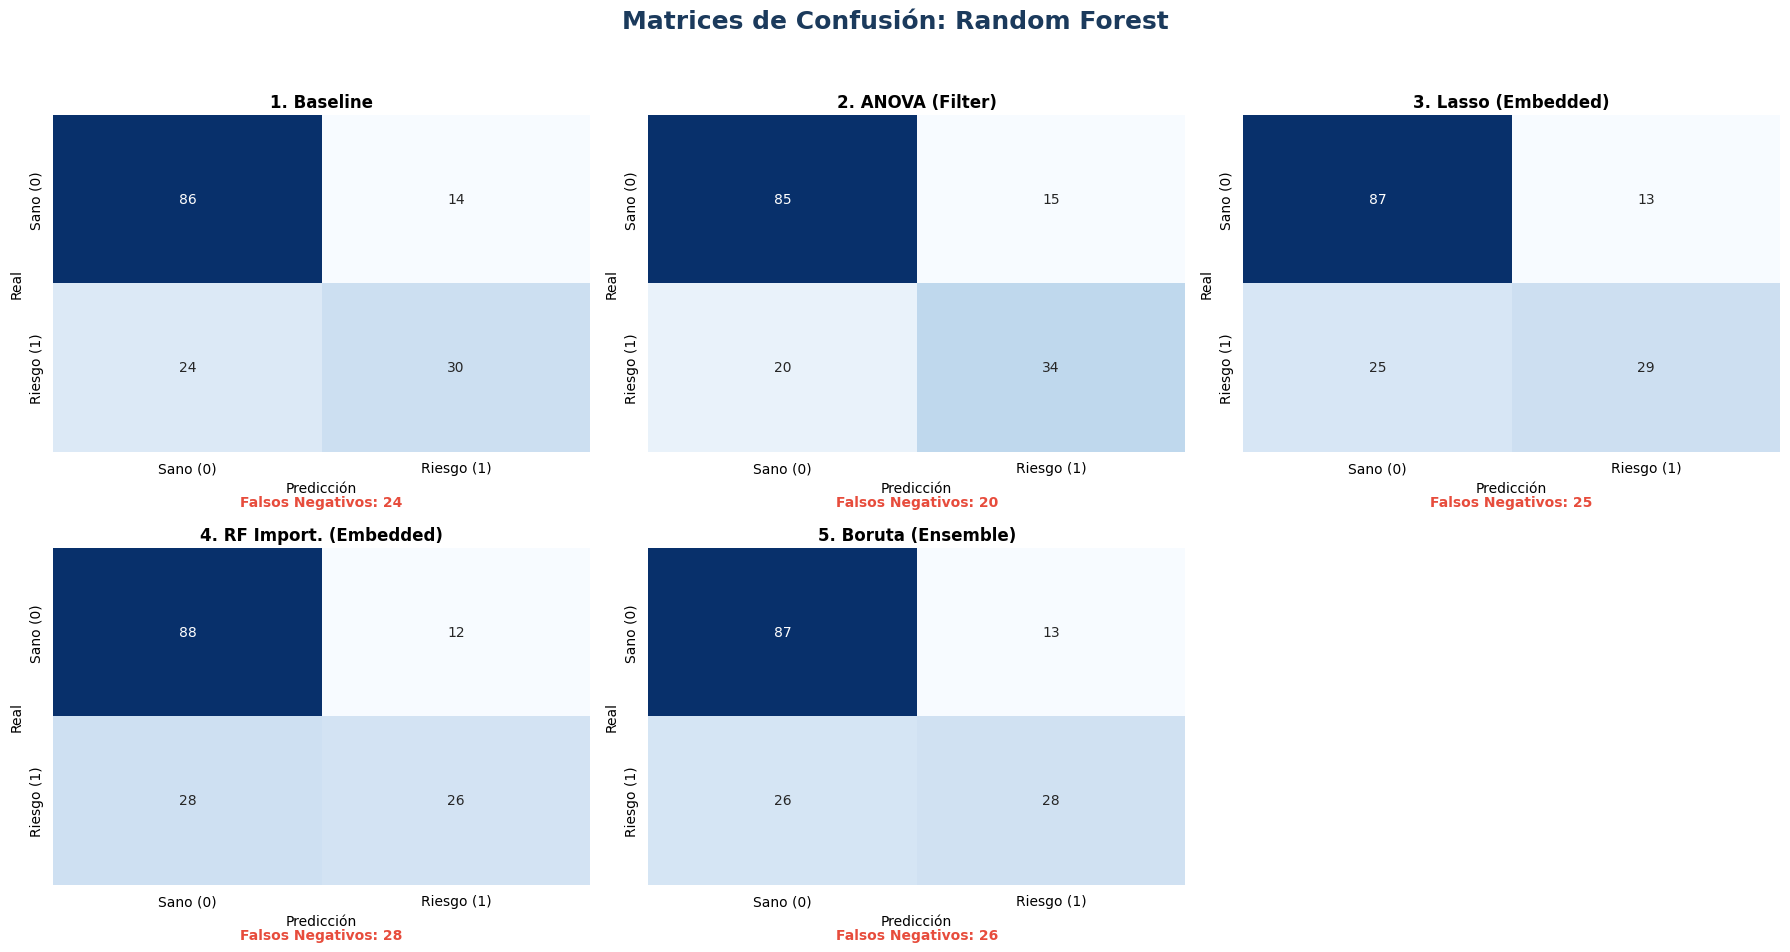

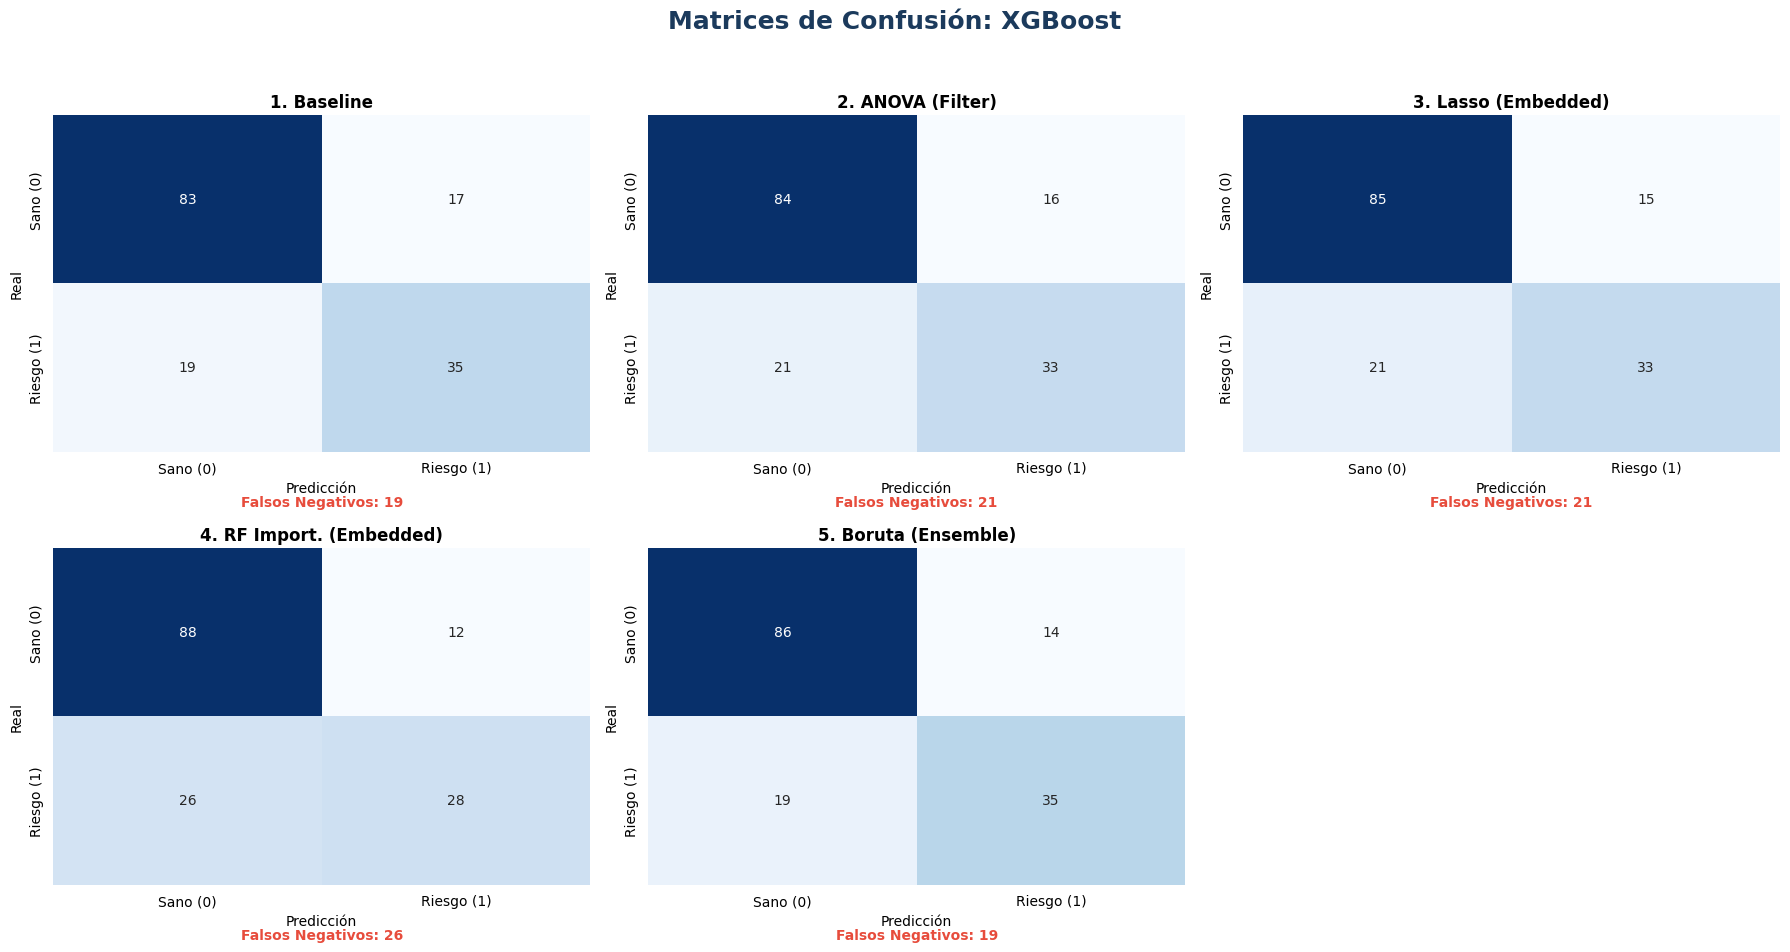

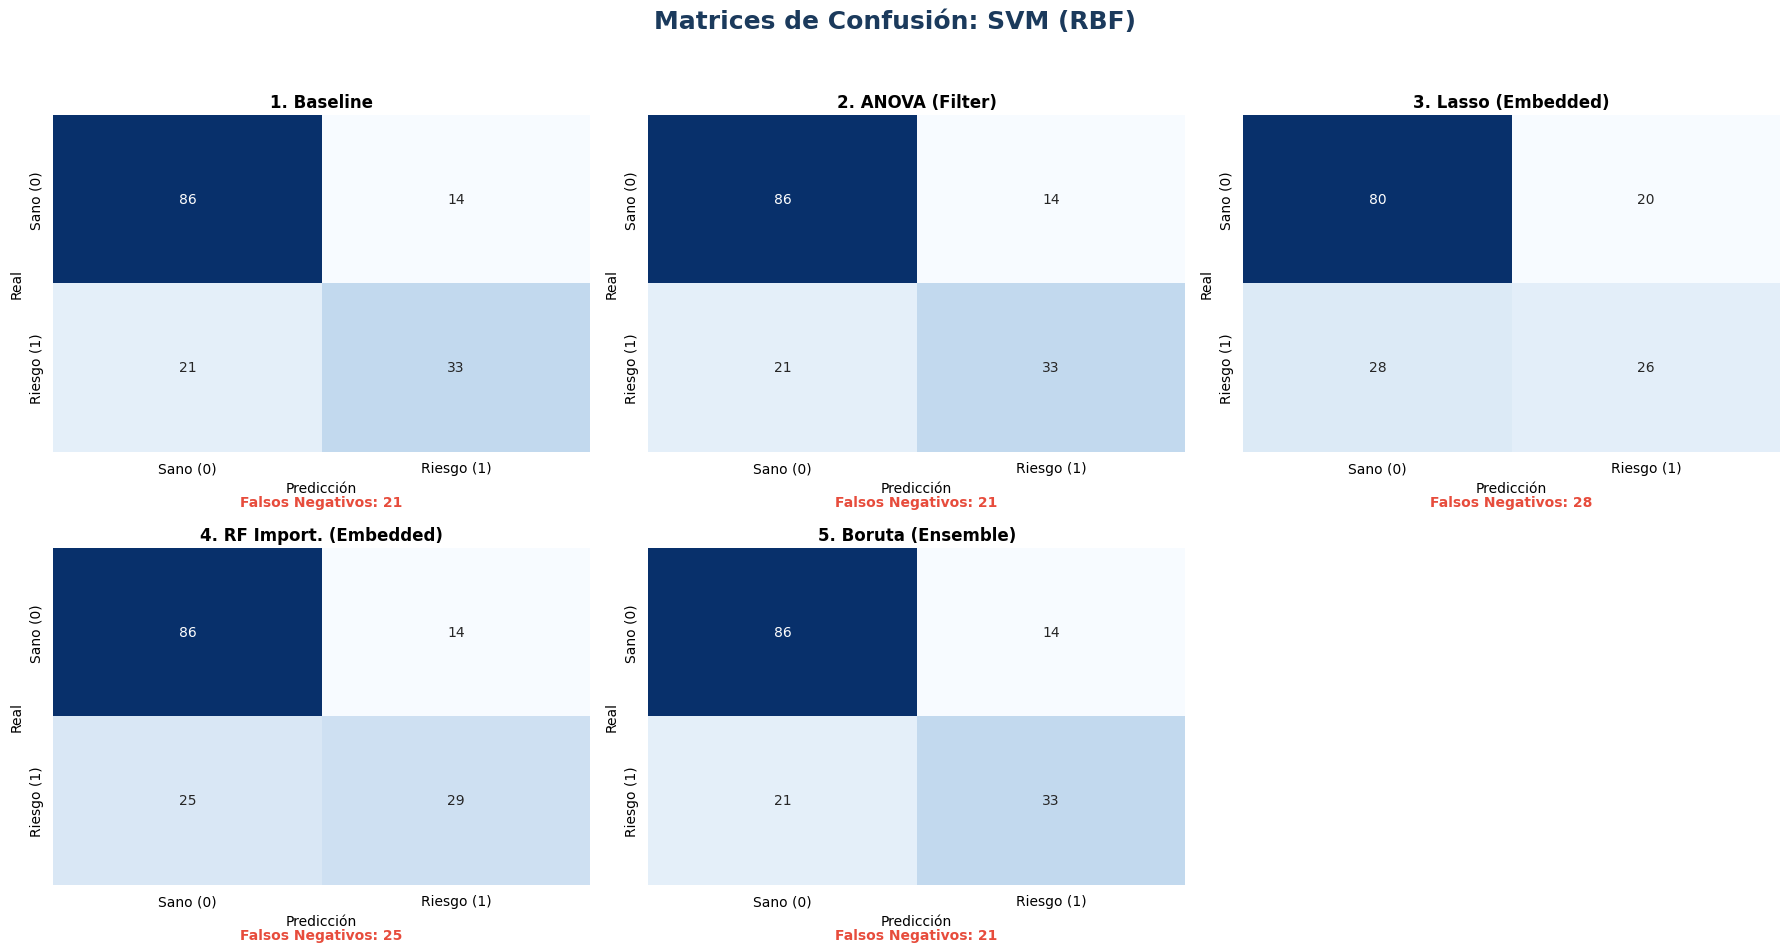

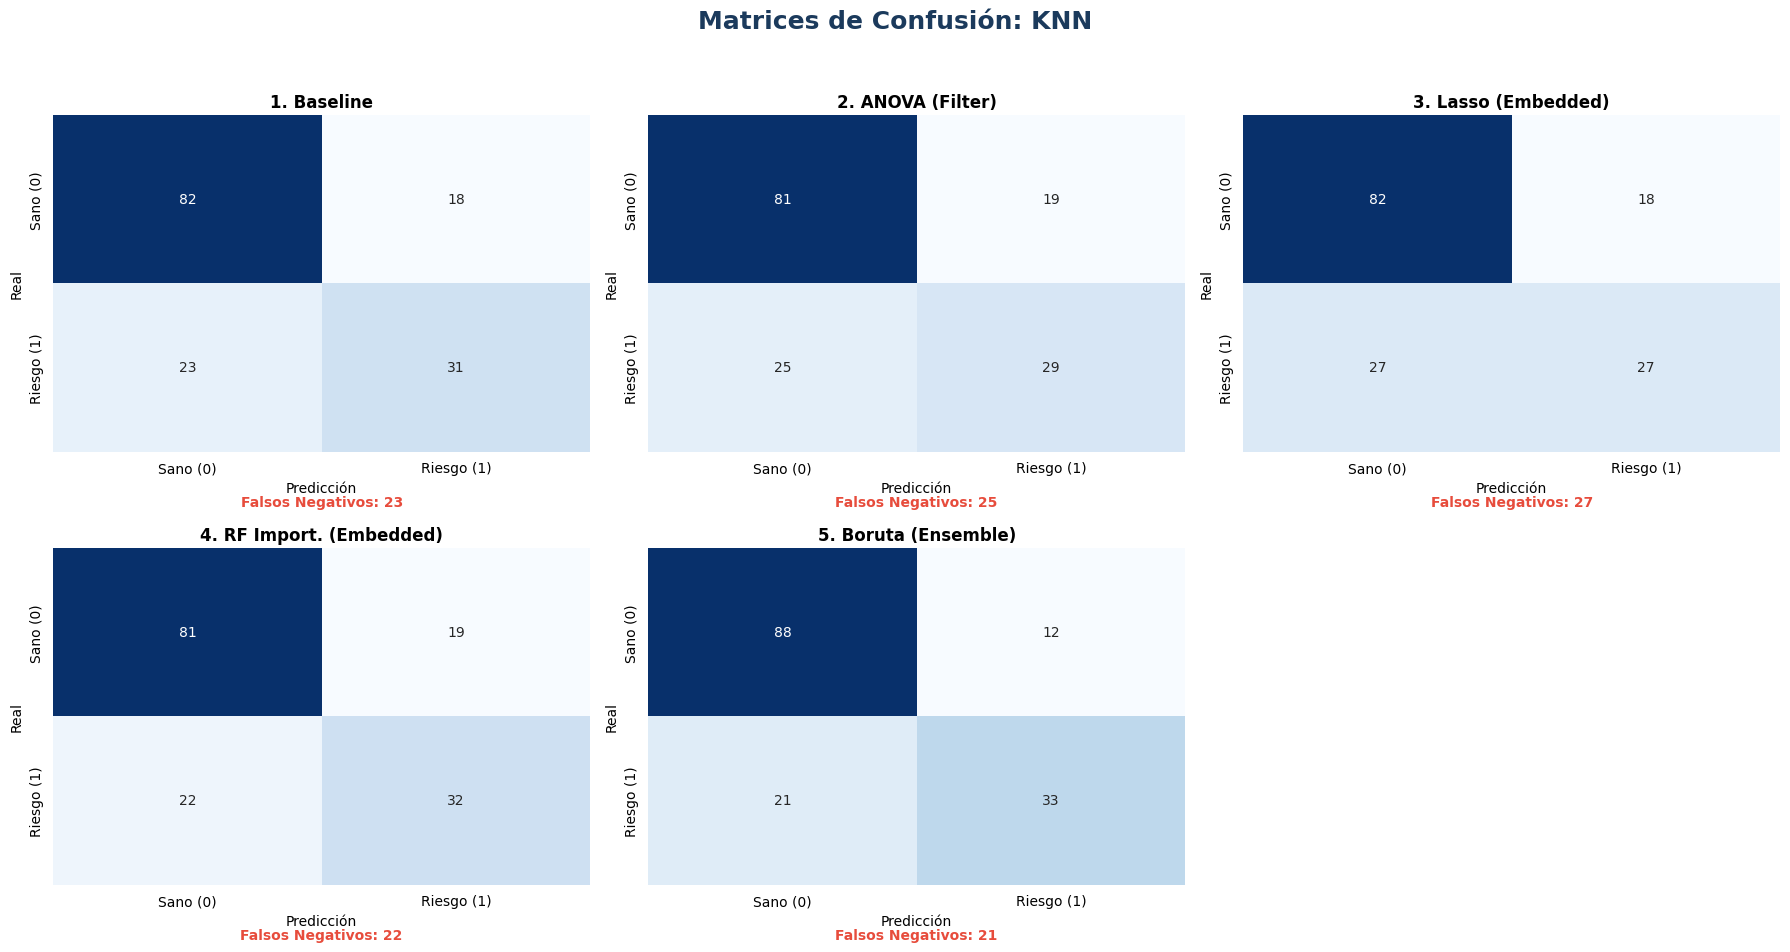

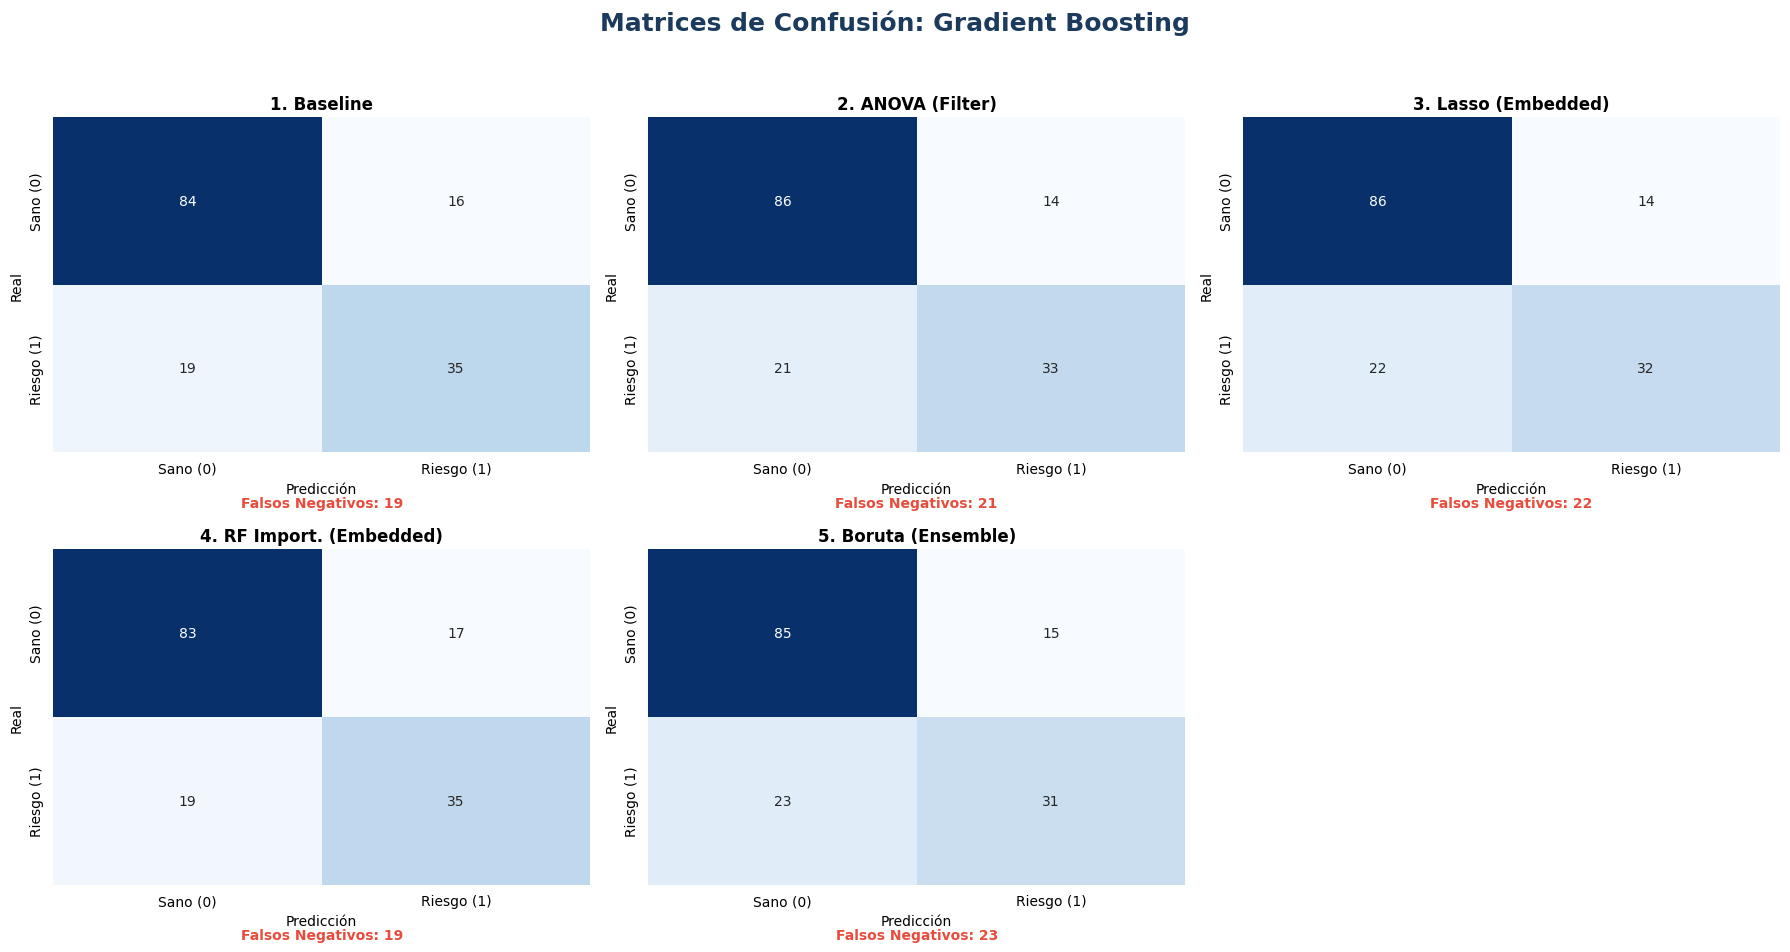

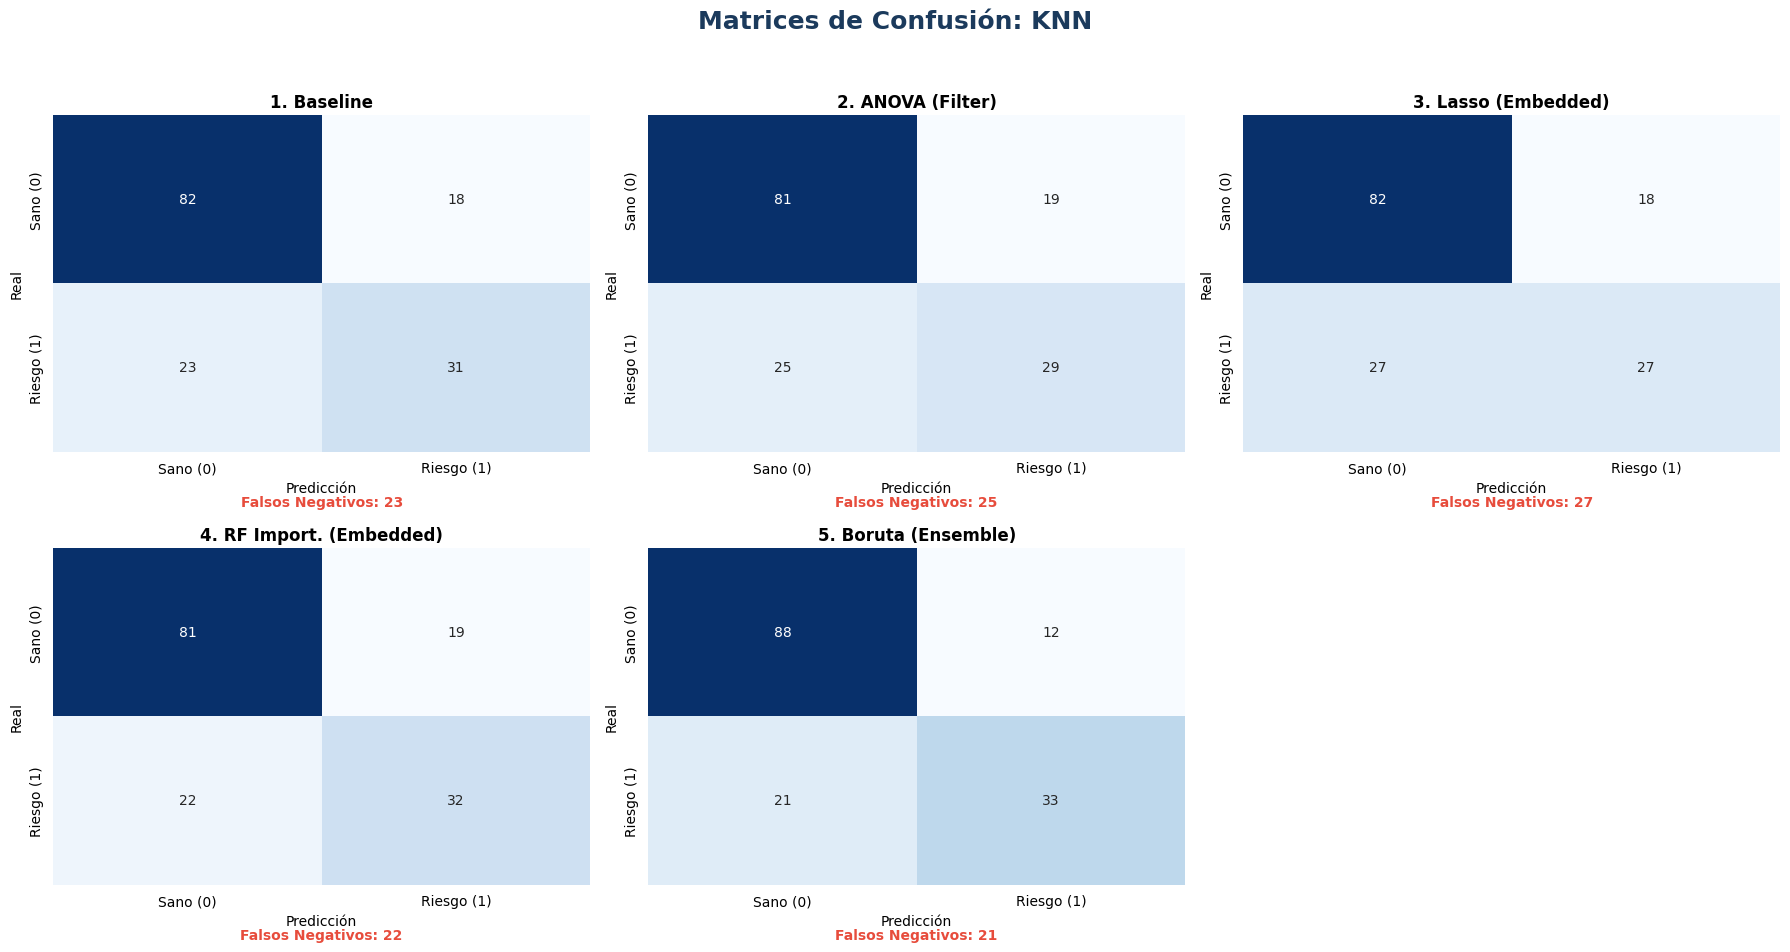

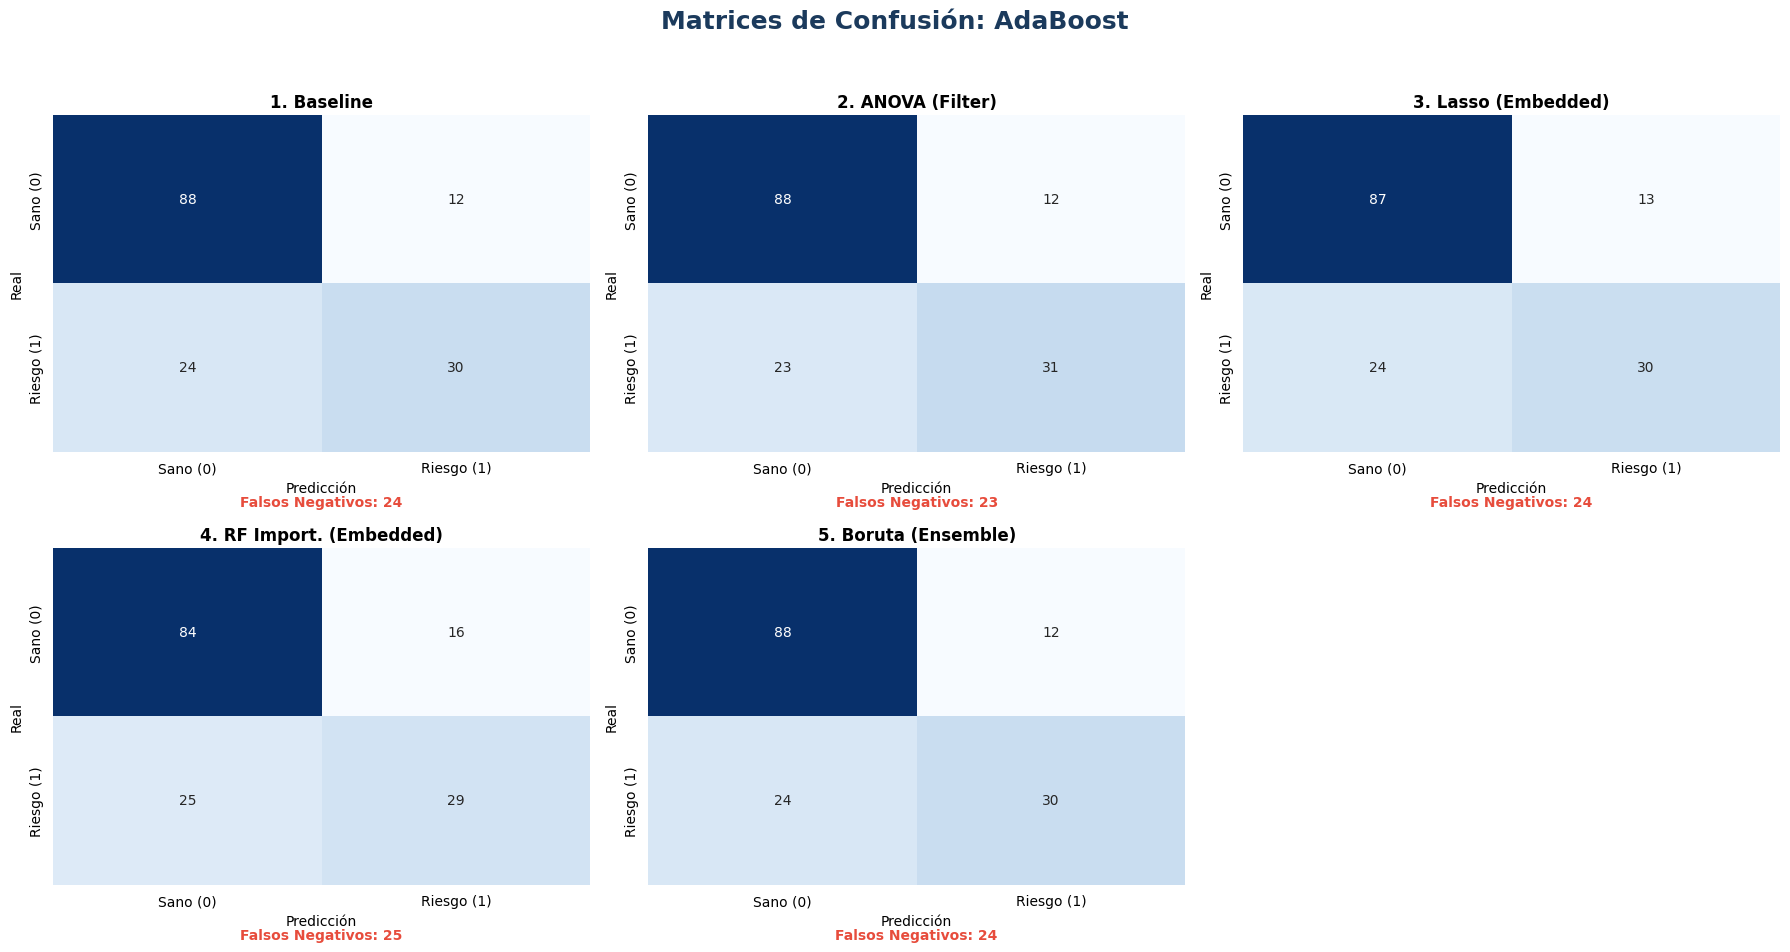

In [220]:
# ==========================================
# 📊 BLOQUE 16: MATRICES DE CONFUSIÓN
# ==========================================
from sklearn.metrics import confusion_matrix

print("📊 Generando Matrices de Confusión detalladas...")

for nombre_modelo, diccionario_pipelines in global_history:
    n_estrategias = len(diccionario_pipelines)

    # Configuración dinámica de subplots (3 columnas por fila)
    n_cols = 3
    n_rows = int(np.ceil(n_estrategias / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() if n_estrategias > 1 else [axes]

    for i, (nombre_estrategia, pipeline) in enumerate(diccionario_pipelines.items()):
        # A. Predicción
        y_pred = pipeline.predict(X_test_selected)

        # B. Matriz
        cm = confusion_matrix(y_test, y_pred)

        # C. Gráfico
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                    xticklabels=['Sano (0)', 'Riesgo (1)'],
                    yticklabels=['Sano (0)', 'Riesgo (1)'])

        axes[i].set_title(f"{nombre_estrategia}", fontweight='bold', fontsize=12)
        axes[i].set_xlabel('Predicción')
        axes[i].set_ylabel('Real')

        # D. Anotación de FN (Falsos Negativos - Error crítico en salud)
        tn, fp, fn, tp = cm.ravel()
        axes[i].text(0.5, -0.15, f'Falsos Negativos: {fn}', ha='center', va='center',
                     transform=axes[i].transAxes, color='#E74C3C', fontweight='bold')

    # Limpiar ejes sobrantes si hay menos de 6 estrategias
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Matrices de Confusión: {nombre_modelo}', fontsize=18, fontweight='bold', color='#1B3A5C')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [223]:
# ==========================================
# 🏆 BLOQUE 17: TABLA MAESTRA
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

resultados_completos = []

print("🔬 Calculando métricas finales en Test Set...")

for nombre_modelo, diccionario_pipelines in global_history:
    for nombre_estrategia, pipeline in diccionario_pipelines.items():

        # 1. Predicciones
        y_pred = pipeline.predict(X_test_selected)
        y_proba = pipeline.predict_proba(X_test_selected)[:, 1]

        # 2. Cálculo de Métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        # 3. Guardado (Sin parámetros)
        resultados_completos.append({
            'Modelo': nombre_modelo,
            'Estrategia': nombre_estrategia,
            'Recall': rec,
            'Precision': prec,
            'F1 Score': f1,
            'AUC': auc,
            'Accuracy': acc
        })

# 4. Creación y Ordenamiento del DataFrame
df_master = pd.DataFrame(resultados_completos)
df_master = df_master.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

# 5. Visualización TOP 3 (FIX FORMATTING)
fmt = "{:.4f}"
subset_cols = ['Recall', 'Precision', 'F1 Score', 'AUC', 'Accuracy']

display(
    df_master.head(3).style
    .background_gradient(subset=['Recall', 'F1 Score', 'AUC'], cmap='Greens')
    .format({col: fmt for col in subset_cols})
)

# 6. Tabla Completa
print("\n📋 TABLA COMPLETA DE RESULTADOS:")
display(df_master)

🔬 Calculando métricas finales en Test Set...


,Modelo,Estrategia,Recall,Precision,F1 Score,AUC,Accuracy
0,Logistic Regression,2. ANOVA (Filter),0.6667,0.7059,0.6857,0.8461,0.7857
1,XGBoost,5. Boruta (Ensemble),0.6481,0.7143,0.6796,0.8204,0.7857
2,KNN,5. Boruta (Ensemble),0.6111,0.7333,0.6667,0.8133,0.7857



📋 TABLA COMPLETA DE RESULTADOS:


,Modelo,Estrategia,Recall,Precision,F1 Score,AUC,Accuracy
0,Logistic Regression,2. ANOVA (Filter),0.666667,0.705882,0.685714,0.846111,0.785714
1,XGBoost,5. Boruta (Ensemble),0.648148,0.714286,0.679612,0.820370,0.785714
2,KNN,5. Boruta (Ensemble),0.611111,0.733333,0.666667,0.813333,0.785714
3,Gradient Boosting,1. Baseline,0.648148,0.686275,0.666667,0.821296,0.772727
4,KNN,5. Boruta (Ensemble),0.611111,0.733333,0.666667,0.813333,0.785714
5,Gradient Boosting,4. RF Import. (Embedded),0.648148,0.673077,0.660377,0.804444,0.766234
6,XGBoost,1. Baseline,0.648148,0.673077,0.660377,0.826111,0.766234
7,Random Forest,2. ANOVA (Filter),0.629630,0.693878,0.660194,0.828889,0.772727
8,SVM (RBF),5. Boruta (Ensemble),0.611111,0.702128,0.653465,0.768333,0.772727
9,Gradient Boosting,2. ANOVA (Filter),0.611111,0.702128,0.653465,0.821667,0.772727


📊 Calculando Intervalos de Confianza (95% - Bootstrap)...


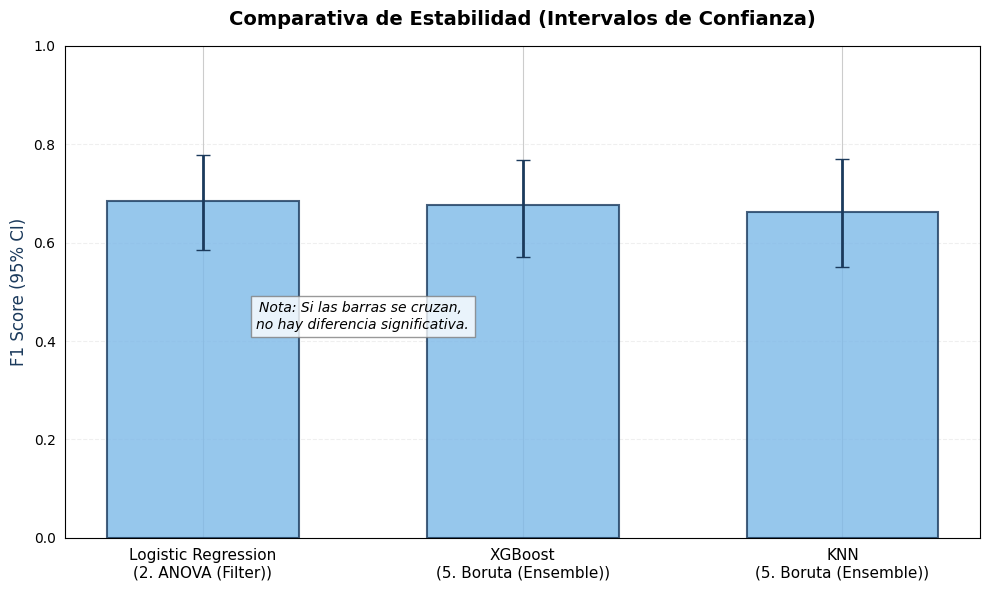

,Modelo,F1 Score,Cota Inf,Cota Sup
0,Logistic Regression (2. ANOVA (Filter)),0.6855,0.5849,0.7778
1,XGBoost (5. Boruta (Ensemble)),0.6756,0.5714,0.7679
2,KNN (5. Boruta (Ensemble)),0.6626,0.5510,0.7709


In [228]:
# ==========================================
# 📊 BLOQUE 18 FINAL: INTERVALOS DE CONFIANZA
# ==========================================
from sklearn.utils import resample
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Top 3 Configuraciones
top_3_config = [
    ('Logistic Regression', '2. ANOVA (Filter)'),
    ('XGBoost', '5. Boruta (Ensemble)'),
    ('KNN', '5. Boruta (Ensemble)')
]

# 2. Función de IC Robusta
def calcular_ic_metrica(y_true, y_pred, n_iteraciones=1000, ci=95):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    bootstrapped_scores = []

    for i in range(n_iteraciones):
        y_true_boot = resample(y_true_arr, random_state=i)
        y_pred_boot = resample(y_pred_arr, random_state=i)

        score = f1_score(y_true_boot, y_pred_boot)
        bootstrapped_scores.append(score)

    lower = np.percentile(bootstrapped_scores, (100 - ci) / 2)
    upper = np.percentile(bootstrapped_scores, 100 - (100 - ci) / 2)
    mean_score = np.mean(bootstrapped_scores)

    return mean_score, lower, upper

# 3. Ejecución
datos_grafico = []
print("📊 Calculando Intervalos de Confianza (95% - Bootstrap)...")

for nombre_modelo, nombre_estrategia in top_3_config:
    pipeline = None
    for n_mod, dict_pipes in global_history:
        if n_mod == nombre_modelo and nombre_estrategia in dict_pipes:
            pipeline = dict_pipes[nombre_estrategia]
            break

    if pipeline:
        y_pred = pipeline.predict(X_test_selected)
        media, lower, upper = calcular_ic_metrica(y_test, y_pred)

        datos_grafico.append({
            'Modelo': f'{nombre_modelo}\n({nombre_estrategia})',
            'F1 Score': media,
            'Cota Inf': lower,
            'Cota Sup': upper
        })

# 4. Visualización
df_ic = pd.DataFrame(datos_grafico).sort_values('F1 Score', ascending=False)

plt.figure(figsize=(10, 6), facecolor='white')
pos = np.arange(len(df_ic))

bars = plt.bar(pos, df_ic['F1 Score'], color='#7CB9E8',
               edgecolor='#1B3A5C', linewidth=1.5, alpha=0.8, width=0.6)

plt.errorbar(pos, df_ic['F1 Score'],
             yerr=[df_ic['F1 Score'] - df_ic['Cota Inf'],
                    df_ic['Cota Sup'] - df_ic['F1 Score']],
             fmt='none', ecolor='#1B3A5C', elinewidth=2, capsize=5)

plt.xticks(pos, df_ic['Modelo'], fontsize=11)
plt.ylabel('F1 Score (95% CI)', fontsize=12, color='#1B3A5C')
plt.title('Comparativa de Estabilidad (Intervalos de Confianza)', fontsize=14, fontweight='bold', pad=15)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.text(0.5, 0.45, "Nota: Si las barras se cruzan, \nno hay diferencia significativa.",
         ha='center', va='center', fontsize=10, style='italic',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

# 5. Tabla Formateada (CORREGIDO)
fmt_cols = {'F1 Score': "{:.4f}", 'Cota Inf': "{:.4f}", 'Cota Sup': "{:.4f}"}

display(
    df_ic[['Modelo', 'F1 Score', 'Cota Inf', 'Cota Sup']]
    .style
    .format(fmt_cols)
)

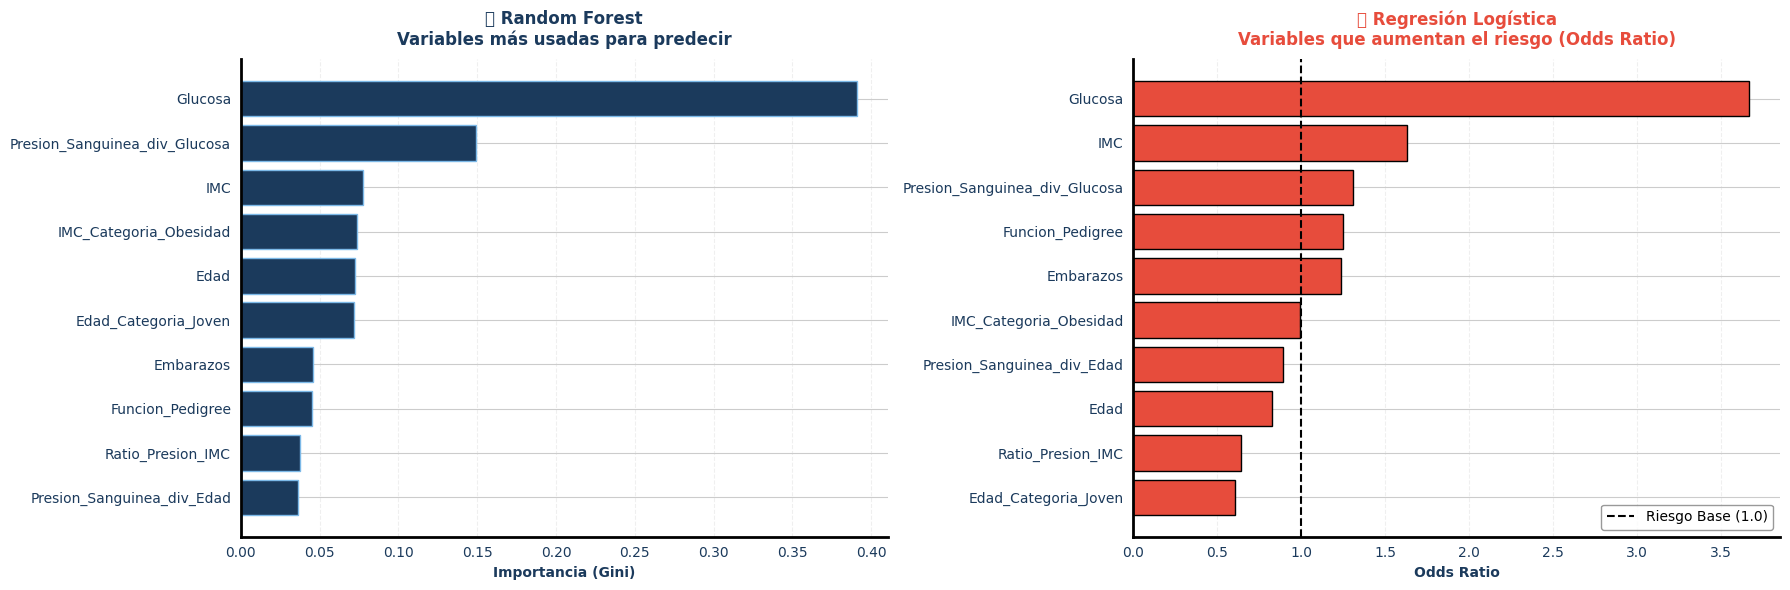

📊 Tabla de Odds Ratios (Regresión Logística):


,Variable,Odds Ratio
2,Glucosa,3.67
4,IMC,1.63
7,Presion_Sanguinea_div_Glucosa,1.31
5,Funcion_Pedigree,1.25
3,Embarazos,1.24
9,IMC_Categoria_Obesidad,0.99
8,Presion_Sanguinea_div_Edad,0.89
6,Edad,0.83
1,Ratio_Presion_IMC,0.64
0,Edad_Categoria_Joven,0.61


In [245]:
# ==========================================
# 🎨 BLOQUE 20: VISUALIZACIÓN Y TABLAS
# ==========================================

# 1. ASEGURAR DATOS
pipe_rf_vis = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=10)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1))
])
pipe_rf_vis.fit(X_train_selected, y_train)

pipe_log_vis = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=10)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])
pipe_log_vis.fit(X_train_selected, y_train)

# 2. EXTRACCIÓN DE DATOS
rf_cols = X_train_selected.columns[pipe_rf_vis.named_steps['selector'].get_support()]
rf_imp = pipe_rf_vis.named_steps['rf'].feature_importances_
df_rf = pd.DataFrame({'Variable': rf_cols, 'Importancia': rf_imp})
df_rf = df_rf.sort_values('Importancia', ascending=False).head(10)

# --- Regresión Logística (Objetivo: Barras grandes arriba) ---
log_cols = X_train_selected.columns[pipe_log_vis.named_steps['selector'].get_support()]
log_coef = pipe_log_vis.named_steps['logreg'].coef_[0]
df_log = pd.DataFrame({'Variable': log_cols, 'Odds Ratio': np.exp(log_coef)})
# Estrategia: Orden Descendente (Mayor -> Menor) + Sin invertir eje Y
df_log = df_log.sort_values('Odds Ratio', ascending=False).head(10)

# 3. VISUALIZACIÓN
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='white')

# --- IZQUIERDA: RF (Grandes Abajo) ---
axes[0].barh(df_rf['Variable'], df_rf['Importancia'], color='#1B3A5C', edgecolor='#7CB9E8', linewidth=1)
axes[0].set_title('🧠 Random Forest\nVariables más usadas para predecir', fontweight='bold', color='#1B3A5C', fontsize=12, pad=10)
axes[0].set_xlabel('Importancia (Gini)', fontweight='bold', color='#1B3A5C')
axes[0].invert_yaxis()
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_linewidth(2)
axes[0].spines['bottom'].set_linewidth(2)

# --- DERECHA: LOGREG (Grandes Arriba) ---
axes[1].barh(df_log['Variable'][::-1],df_log['Odds Ratio'][::-1],color='#E74C3C',edgecolor='black',linewidth=1)
axes[1].axvline(1, color='black', linestyle='--', linewidth=1.5, label='Riesgo Base (1.0)')
axes[1].set_title('🩺 Regresión Logística\nVariables que aumentan el riesgo (Odds Ratio)', fontweight='bold', color='#E74C3C', fontsize=12, pad=10)
axes[1].set_xlabel('Odds Ratio', fontweight='bold', color='#1B3A5C')
axes[1].legend(loc='lower right', facecolor='white', edgecolor='gray')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_linewidth(2)
axes[1].spines['bottom'].set_linewidth(2)

# Estética General
for ax in axes:
    ax.tick_params(axis='both', colors='#1B3A5C', labelsize=10)
    ax.set_facecolor('white')

plt.tight_layout()
plt.show()

# ==========================================
# 📋 TABLA DE ODDS RATIOS (ESTILO CORPORATIVO)
# ==========================================
print("📊 Tabla de Odds Ratios (Regresión Logística):")

display(
    df_log.style
    .background_gradient(subset=['Odds Ratio'], cmap='Reds', axis=0)
    .format({"Odds Ratio": "{:.2f}"})
    .set_properties(**{
        'background-color': '#f1f5f9',
        'color': '#1B3A5C',
        'font-weight': 'bold'
    }, subset=['Variable'])
    .set_table_styles([{
        'selector': 'td:hover',
        'props': 'background-color: #e2e8f0; color: black;'
    }])
)

📊 COMPARACIÓN REAL: RAW vs FEATURE ENGINEERING
----------------------------------------------------------------------


,Variable,Odds Ratio (Raw),Odds Ratio (Engineered),Diferencia
3,Glucosa,1.04,3.67,+2.63
2,IMC,1.10,1.63,+0.53
1,Embarazos,1.12,1.24,+0.12
4,Edad,1.02,0.83,-0.19
0,Funcion_Pedigree,2.05,1.25,-0.81



🧪 VARIABLES NUEVAS GENERADAS POR FEATURE ENGINEERING
----------------------------------------------------------------------


,Variable,Odds Ratio (Engineered)
7,Presion_Sanguinea_div_Glucosa,1.31
9,IMC_Categoria_Obesidad,0.99
8,Presion_Sanguinea_div_Edad,0.89
1,Ratio_Presion_IMC,0.64
0,Edad_Categoria_Joven,0.61


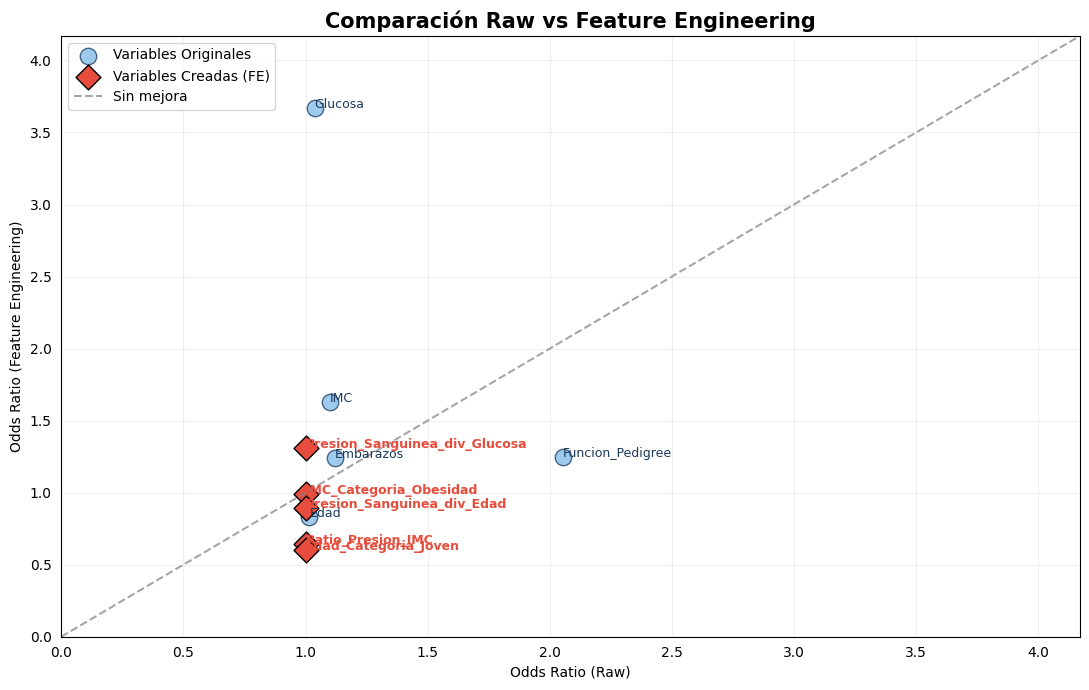

In [254]:
# ==========================================
# CONFIGURACIÓN VISUAL
# ==========================================
COLOR_DARK = '#1B3A5C'  # Azul Oscuro
COLOR_LIGHT = '#7CB9E8' # Celeste
COLOR_RISK = '#E74C3C'  # Rojo Riesgo

# ==========================================
# 1. MODELO BASE (RAW DATA)
# ==========================================
cols_crudas = ['Glucosa', 'IMC', 'Presion_Sanguinea', 'Edad', 'Embarazos', 'Funcion_Pedigree', 'Insulina']

log_base = LogisticRegression(max_iter=1000, random_state=42)
log_base.fit(X_train[cols_crudas], y_train)

df_base = pd.DataFrame({
    'Variable': cols_crudas,
    'OR_Raw': np.exp(log_base.coef_[0])
}).sort_values('OR_Raw', ascending=False)

# ==========================================
# 2. MODELO GANADOR (FEATURE ENGINEERING)
# ==========================================
# Asumimos pipe_log_vis es el pipeline ganador (LogReg + ANOVA)
selector_mask = pipe_log_vis.named_steps['selector'].get_support()
features_seleccionadas = X_train_selected.columns[selector_mask]
coefs_ganador = pipe_log_vis.named_steps['logreg'].coef_[0]

df_ganador = pd.DataFrame({
    'Variable': features_seleccionadas,
    'OR_FE': np.exp(coefs_ganador)
}).sort_values('OR_FE', ascending=False)

# ==========================================
# 3. COMPARACIÓN Y DIFERENCIA
# ==========================================
df_comp = pd.merge(df_base, df_ganador, on='Variable', how='inner')
df_comp['Delta'] = df_comp['OR_FE'] - df_comp['OR_Raw']
df_comp = df_comp.sort_values('Delta', ascending=False)

# ==========================================
# 4. VARIABLES NUEVAS (CREADAS POR FE)
# ==========================================
df_nuevas = df_ganador[~df_ganador['Variable'].isin(df_base['Variable'])]

# ==========================================
# 5. VISUALIZACIÓN DE DATOS (TABLAS)
# ==========================================

# Tabla Comparativa
styler_comp = (
    df_comp.style
    .background_gradient(subset=['OR_Raw', 'OR_FE', 'Delta'], cmap='RdYlGn')
    .format({'OR_Raw': '{:.2f}', 'OR_FE': '{:.2f}', 'Delta': '{:+.2f}'})
    .set_properties(subset=['Variable'], **{'font-weight': 'bold', 'color': COLOR_DARK})
)

# Tabla Nuevas Variables
styler_nuevas = (
    df_nuevas.style
    .background_gradient(subset=['OR_FE'], cmap='Blues')
    .format({'OR_FE': '{:.2f}'})
    .set_caption("Variables Generadas por Feature Engineering")
)

display(styler_comp)
if not df_nuevas.empty:
    display(styler_nuevas)

# ==========================================
# 6. GRÁFICO DE IMPACTO (RAW VS ENGINEERED)
# ==========================================
df_plot = df_comp[df_comp['Delta'].abs() > 0.05].copy()

fig, ax = plt.subplots(figsize=(10, 7))

# Variables Compartidas (Scatter Plot)
ax.scatter(
    df_plot['OR_Raw'],
    df_plot['OR_FE'],
    s=120,
    alpha=0.8,
    color=COLOR_LIGHT,
    edgecolor=COLOR_DARK,
    linewidth=1.5,
    label='Variables Originales'
)

# Anotaciones Variables Compartidas
for _, row in df_plot.iterrows():
    ax.annotate(
        row['Variable'],
        (row['OR_Raw'], row['OR_FE']),
        fontsize=9,
        color=COLOR_DARK,
        xytext=(5, 5),
        textcoords='offset points'
    )

# Variables Nuevas (Marcador Distintivo)
if not df_nuevas.empty:
    # Se ubican en X=1 (Neutro) para visualización comparativa
    x_nuevas = [1] * len(df_nuevas)
    ax.scatter(
        x_nuevas,
        df_nuevas['OR_FE'],
        s=140,
        color=COLOR_RISK,
        edgecolor='black',
        marker='D',
        label='Variables Creadas (FE)',
        zorder=5
    )

    # Anotaciones Nuevas Variables
    for _, row in df_nuevas.iterrows():
        ax.annotate(
            row['Variable'],
            (1, row['OR_FE']),
            fontsize=9,
            color=COLOR_RISK,
            fontweight='bold',
            ha='left',
            va='center',
            xytext=(10, 0),
            textcoords='offset points'
        )

# Línea de Referencia (Sin Cambio)
max_val = max(
    df_plot['OR_FE'].max(),
    df_plot['OR_Raw'].max(),
    df_nuevas['OR_FE'].max() if not df_nuevas.empty else 0
) + 0.5

ax.plot([0, max_val], [0, max_val], '--', color='gray', alpha=0.5, linewidth=1, label='Sin Cambio (y=x)')

# Estética Final
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_title('Impacto del Feature Engineering: Odds Ratios', fontsize=14, fontweight='bold', color=COLOR_DARK, pad=20)
ax.set_xlabel('Odds Ratio (Raw)', fontsize=11, color=COLOR_DARK)
ax.set_ylabel('Odds Ratio (Feature Engineering)', fontsize=11, color=COLOR_DARK)

# Grid y Spines
ax.grid(True, linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(COLOR_DARK)
ax.spines['bottom'].set_color(COLOR_DARK)

# Leyenda
legend = ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor=COLOR_DARK)
plt.setp(legend.get_texts(), color=COLOR_DARK, fontsize=9)

plt.tight_layout()
plt.show()

## Conclusiones y análisis de variables

En este proyecto, la variable que más destacó fue **Glucosa**, con un *odds ratio* de 3.67. Esto confirma lo que ya se esperaba desde el punto de vista clínico: cuando la glucosa aumenta, el riesgo de diabetes también lo hace de forma muy marcada. Para mí, este resultado reafirma que la glucosa sigue siendo la señal más fuerte y confiable dentro del modelo.

Respecto al *feature engineering*, considero que sí valió la pena, aunque no en todas las variables por igual. Algunas combinaciones nuevas, como **Presion_Sanguinea_div_Glucosa** (*OR = 1.31*), lograron mostrar relaciones que no se ven tan fácilmente en las variables originales. Eso me pareció interesante, porque permitió descubrir perfiles fisiológicos que podrían pasar desapercibidos si solo se usan los datos crudos. De forma similar, variables como **Presion_Sanguinea_div_Edad** (*OR = 0.89*) y **Ratio_Presion_IMC** (*OR = 0.64*) ayudaron a entender mejor cómo interactúan la presión, la edad y el IMC en el riesgo de diabetes.

Sin embargo, no todas las transformaciones aportaron lo mismo. Por ejemplo, **IMC_Categoria_Obesidad** (*OR ≈ 0.99*) prácticamente no añadió valor, lo que me hizo notar que convertir una variable numérica en una categoría puede hacer perder información importante. Algo parecido pasó con **Edad_Categoria_Joven** (*OR = 0.61*), que sí refleja cierta protección biológica por la edad, pero no parece ser tan precisa como usar la edad original. Esto me llevó a concluir que, en este proyecto, las variables numéricas conservan mejor la información que sus versiones categorizadas.

En resumen, mi proyecto me permitió ver que el riesgo de diabetes está fuertemente marcado por la combinación de **glucosa, presión y edad**, y que el *feature engineering* sí puede aportar valor cuando ayuda a descubrir relaciones más profundas entre variables. Aun así, también aprendí que no toda transformación mejora el modelo, por lo que conviene mantener las variables originales cuando estas ofrecen más detalle y precisión.